# 📊 Telecom Customer Churn Analysis — Industry-Standard EDA

---

**Objective:** Perform a complete, industry-standard Exploratory Data Analysis (EDA) on a telecom customer churn dataset to:
- Understand the distribution and quality of the data
- Identify key drivers of customer churn
- Produce publication-ready visualisations with saved outputs
- Package all artefacts into a final ZIP for downstream use

**Dataset:** `Customer-Churn.csv` — Upload manually in Colab before running.

**Author:** [Your Name]  
**Version:** 1.0  
**Last Updated:** 2026-04-28

---

## Table of Contents
1. [Environment Setup](#1.-Environment-Setup)
2. [Data Ingestion](#2.-Data-Ingestion)
3. [Data Profiling & Quality Check](#3.-Data-Profiling-&-Quality-Check)
4. [Data Cleaning & Feature Engineering](#4.-Data-Cleaning-&-Feature-Engineering)
5. [Target Variable Analysis](#5.-Target-Variable-Analysis)
6. [Univariate Analysis](#6.-Univariate-Analysis)
7. [Bivariate Analysis](#7.-Bivariate-Analysis)
8. [Correlation & Heatmap Analysis](#8.-Correlation-&-Heatmap-Analysis)
9. [KDE Charge Distribution by Churn](#9.-KDE-Charge-Distribution-by-Churn)
10. [Business Insights Summary](#10.-Business-Insights-Summary)
11. [Export & ZIP All Outputs](#11.-Export-&-ZIP-All-Outputs)

## 1. Environment Setup

Install and import all required libraries. Set global plot styles, directories, and random seeds for reproducibility.

In [22]:
# ── 1.1  Install any missing packages (Colab-safe) ──────────────────────────
import subprocess, sys

def install_if_missing(pkg):
    """Install a package via pip only if it isn't already importable."""
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["missingno", "phik", "scipy", "statsmodels"]:
    install_if_missing(pkg)

In [23]:
# ── 1.2  Standard library imports ───────────────────────────────────────────
import os
import json
import zipfile
import warnings
import datetime
from pathlib import Path

# ── 1.3  Data manipulation ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── 1.4  Visualisation ──────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno          # missing-value visualisation

# ── 1.5  Statistics ─────────────────────────────────────────────────────────
from scipy import stats
import phik                       # Phi-K correlation (handles categorical+numeric)

# ── 1.6  Global settings ────────────────────────────────────────────────────
warnings.filterwarnings("ignore")        # suppress non-critical warnings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format",  "{:.4f}".format)
np.random.seed(42)                       # reproducibility

# ── 1.7  Plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
sns.set_palette("husl")

# ── 1.8  Output directories ─────────────────────────────────────────────────
# All artefacts are saved here; they'll be zipped at the end.
OUTPUT_DIR   = Path("churn_eda_outputs")
IMG_DIR      = OUTPUT_DIR / "images"
DATA_DIR     = OUTPUT_DIR / "data"
REPORT_DIR   = OUTPUT_DIR / "reports"

for d in [IMG_DIR, DATA_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"✅  Environment ready — outputs will be saved to: {OUTPUT_DIR.resolve()}")
print(f"    NumPy {np.__version__} | Pandas {pd.__version__} | Seaborn {sns.__version__}")

✅  Environment ready — outputs will be saved to: /content/churn_eda_outputs
    NumPy 2.0.2 | Pandas 2.2.2 | Seaborn 0.13.2


## 2. Data Ingestion

> **Colab users:** Upload `Customer-Churn.csv` via the Files panel (left sidebar) before running this cell.

In [24]:
# ── 2.1  Load dataset ───────────────────────────────────────────────────────
# The file is expected in the same directory as this notebook.
# Adjust the path if you placed it elsewhere.
DATA_FILE = "Customer-Churn.csv"

try:
    raw_df = pd.read_csv(DATA_FILE)
    print(f"✅  Loaded '{DATA_FILE}'  →  {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
except FileNotFoundError:
    raise FileNotFoundError(
        f"❌  '{DATA_FILE}' not found.\n"
        "Please upload the file to Colab and re-run this cell."
    )

✅  Loaded 'Customer-Churn.csv'  →  7,043 rows × 21 columns


In [25]:
# ── 2.2  Initial peek ───────────────────────────────────────────────────────
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(raw_df.head())

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
display(raw_df.tail())

# Save raw snapshot
raw_df.to_csv(DATA_DIR / "01_raw_data.csv", index=False)
print(f"\n💾  Raw data snapshot saved → {DATA_DIR / '01_raw_data.csv'}")

FIRST 5 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes



LAST 5 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.8000,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.2000,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.6000,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.4000,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.6500,6844.5,No



💾  Raw data snapshot saved → churn_eda_outputs/data/01_raw_data.csv


## 3. Data Profiling & Quality Check

In [26]:
# ── 3.1  Schema overview ────────────────────────────────────────────────────
print("=" * 60)
print("COLUMN SCHEMA (dtypes + non-null counts)")
print("=" * 60)
raw_df.info(verbose=True, show_counts=True)

COLUMN SCHEMA (dtypes + non-null counts)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

In [27]:
# ── 3.2  Descriptive statistics ─────────────────────────────────────────────
# Numeric columns
num_desc = raw_df.describe(include=[np.number]).T
num_desc["cv"] = num_desc["std"] / num_desc["mean"]  # coefficient of variation
num_desc["skew"]  = raw_df.select_dtypes(include=[np.number]).skew()
num_desc["kurt"]  = raw_df.select_dtypes(include=[np.number]).kurt()

print("=" * 60)
print("NUMERIC DESCRIPTIVE STATS")
print("=" * 60)
display(num_desc)

# Categorical columns
cat_desc = raw_df.describe(include=[object]).T
print("\n" + "=" * 60)
print("CATEGORICAL DESCRIPTIVE STATS")
print("=" * 60)
display(cat_desc)

# Save stats
num_desc.to_csv(REPORT_DIR / "03_numeric_stats.csv")
cat_desc.to_csv(REPORT_DIR  / "03_categorical_stats.csv")
print("\n💾  Descriptive stats saved.")

NUMERIC DESCRIPTIVE STATS


,count,mean,std,min,25%,50%,75%,max,cv,skew,kurt
SeniorCitizen,7043.0000,0.1621,0.3686,0.0000,0.0000,0.0000,0.0000,1.0000,2.2733,1.8336,1.3626
tenure,7043.0000,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000,0.7587,0.2395,-1.3874
MonthlyCharges,7043.0000,64.7617,30.0900,18.2500,35.5000,70.3500,89.8500,118.7500,0.4646,-0.2205,-1.2573



CATEGORICAL DESCRIPTIVE STATS


,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095



💾  Descriptive stats saved.


✅  No missing values detected in the raw dataset.


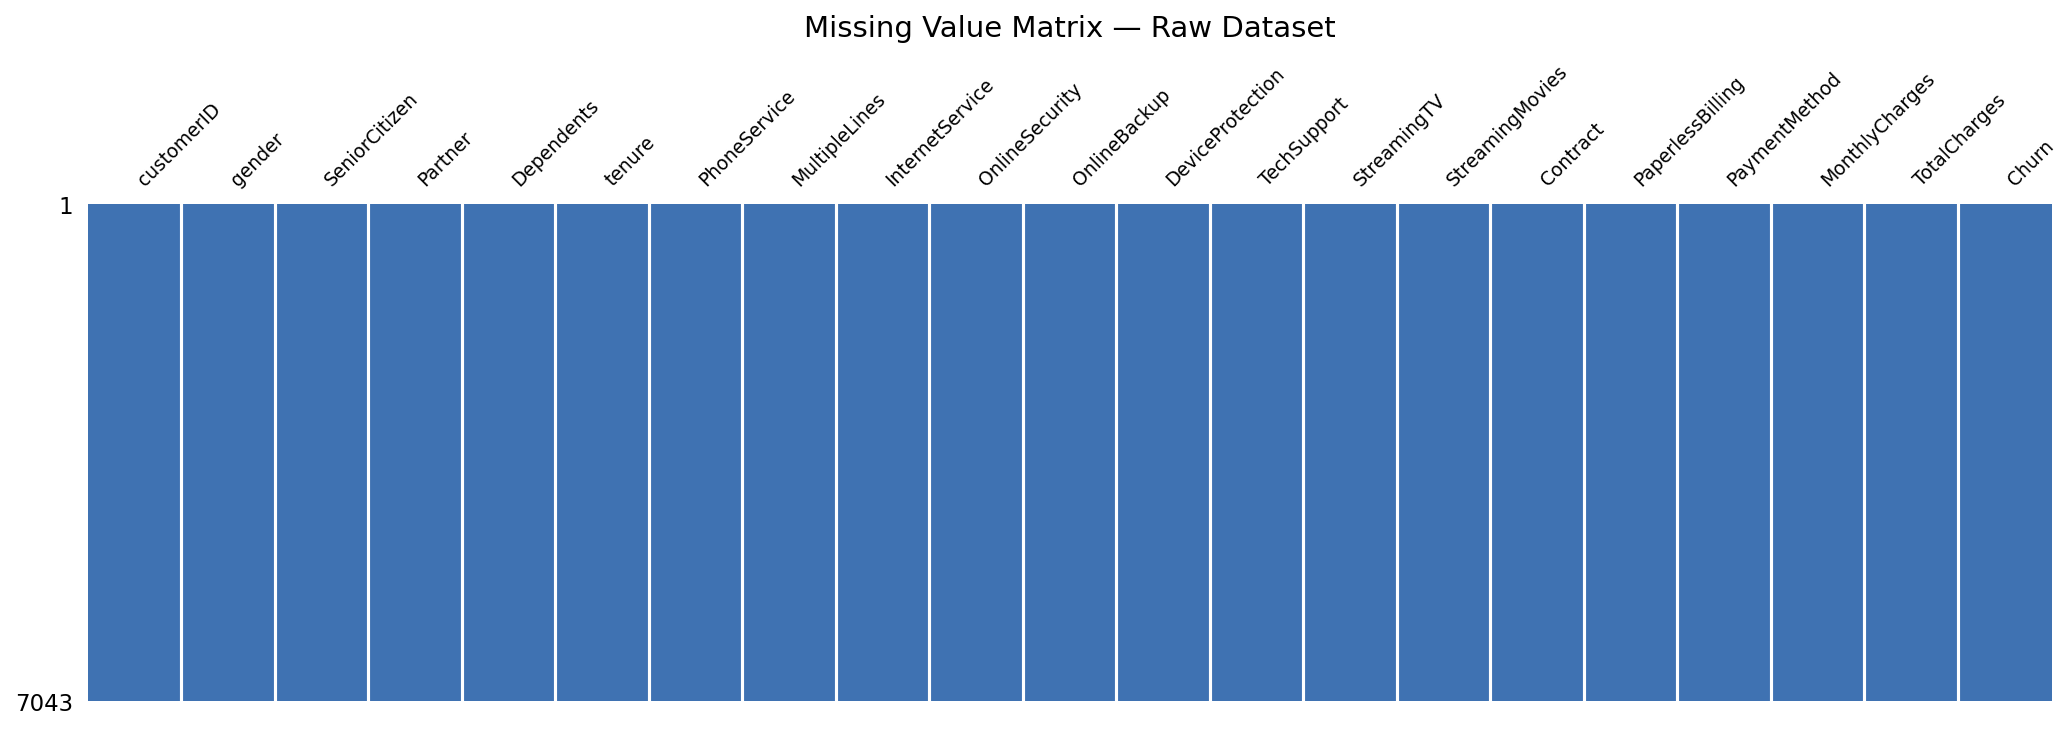

💾  Missing matrix saved.


In [28]:
# ── 3.3  Missing value audit ─────────────────────────────────────────────────
missing_counts = raw_df.isnull().sum()
missing_pct    = (missing_counts / len(raw_df) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct":   missing_pct
}).sort_values("missing_pct", ascending=False)
missing_df = missing_df[missing_df["missing_count"] > 0]

if missing_df.empty:
    print("✅  No missing values detected in the raw dataset.")
else:
    print("⚠️  Missing values detected:")
    display(missing_df)

# Visual: missingno matrix
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(raw_df, ax=ax, color=(0.25, 0.45, 0.70), fontsize=9)
ax.set_title("Missing Value Matrix — Raw Dataset", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(IMG_DIR / "03a_missing_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Missing matrix saved.")

In [29]:
# ── 3.4  Duplicate row check ─────────────────────────────────────────────────
n_dups = raw_df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")
if n_dups > 0:
    print("  → Duplicates will be removed during cleaning.")
else:
    print("  → No duplicates found. ✅")

# ── 3.5  Unique value cardinality per column ─────────────────────────────────
cardinality = raw_df.nunique().reset_index()
cardinality.columns = ["column", "unique_values"]
cardinality["dtype"] = raw_df.dtypes.values
cardinality.sort_values("unique_values", ascending=False, inplace=True)
print("\nColumn cardinality:")
display(cardinality)
cardinality.to_csv(REPORT_DIR / "03_cardinality.csv", index=False)
print("💾  Cardinality report saved.")

Duplicate rows: 0
  → No duplicates found. ✅

Column cardinality:


,column,unique_values,dtype
0,customerID,7043,object
19,TotalCharges,6531,object
18,MonthlyCharges,1585,float64
5,tenure,73,int64
17,PaymentMethod,4,object
14,StreamingMovies,3,object
12,TechSupport,3,object
10,OnlineBackup,3,object
13,StreamingTV,3,object
11,DeviceProtection,3,object


💾  Cardinality report saved.


## 4. Data Cleaning & Feature Engineering

In [30]:
# ── 4.1  Create working copy (never mutate raw_df) ───────────────────────────
df = raw_df.copy()
print(f"Working copy created: {df.shape}")

Working copy created: (7043, 21)


In [31]:
# ── 4.2  Fix TotalCharges dtype ──────────────────────────────────────────────
# TotalCharges is stored as object; coerce to float (invalid → NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"TotalCharges dtype after coercion: {df['TotalCharges'].dtype}")
print(f"NaNs introduced by coercion: {df['TotalCharges'].isnull().sum()}")

TotalCharges dtype after coercion: float64
NaNs introduced by coercion: 11


In [32]:
# ── 4.3  Inspect rows with NaN TotalCharges ──────────────────────────────────
nan_rows = df[df["TotalCharges"].isnull()]
print(f"Rows with null TotalCharges: {len(nan_rows)}")
print(f"These represent {len(nan_rows)/len(df)*100:.2f}% of the dataset.")
display(nan_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head(15))

# Insight: Rows with tenure=0 are likely new customers who haven't been billed yet.
# Safe to drop since they represent < 0.5% of the data.
print("\nTenure distribution for NaN TotalCharges rows:")
print(nan_rows["tenure"].value_counts())

Rows with null TotalCharges: 11
These represent 0.16% of the dataset.


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.5500,NaN,No
753,3115-CZMZD,0,20.2500,NaN,No
936,5709-LVOEQ,0,80.8500,NaN,No
1082,4367-NUYAO,0,25.7500,NaN,No
1340,1371-DWPAZ,0,56.0500,NaN,No
3331,7644-OMVMY,0,19.8500,NaN,No
3826,3213-VVOLG,0,25.3500,NaN,No
4380,2520-SGTTA,0,20.0000,NaN,No
5218,2923-ARZLG,0,19.7000,NaN,No
6670,4075-WKNIU,0,73.3500,NaN,No



Tenure distribution for NaN TotalCharges rows:
tenure
0    11
Name: count, dtype: int64


In [33]:
# ── 4.4  Drop NaN rows ───────────────────────────────────────────────────────
before = len(df)
df.dropna(subset=["TotalCharges"], inplace=True)
df.drop_duplicates(inplace=True)
after  = len(df)
print(f"Rows removed: {before - after} ({(before-after)/before*100:.2f}%)")
print(f"Clean dataset: {df.shape}")

Rows removed: 11 (0.16%)
Clean dataset: (7032, 21)


In [34]:
# ── 4.5  Encode binary target (Churn: Yes/No → 1/0) ─────────────────────────
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})
print("Churn target encoded (Churn_Flag):")
print(df["Churn_Flag"].value_counts())

# Overall churn rate
churn_rate = df["Churn_Flag"].mean() * 100
print(f"\nOverall churn rate: {churn_rate:.2f}%")

Churn target encoded (Churn_Flag):
Churn_Flag
0    5163
1    1869
Name: count, dtype: int64

Overall churn rate: 26.58%


In [35]:
# ── 4.6  Tenure buckets ──────────────────────────────────────────────────────
# Group customers into 12-month tenure bands for categorical analysis
max_tenure = df["tenure"].max()
# The bins are generated as [0, 12, 24, 36, 48, 60, 72, 84], which creates 7 intervals.
# The labels list must also contain 7 elements.
# Original labels: ["{0}-{1} mo".format(i, i+11) for i in range(1, max_tenure+1, 12)]
# For max_tenure=72, range(1, 73, 12) -> [1, 13, 25, 37, 49, 61] (6 elements)
# We need one more element to match the 7 bins.
labels = ["{0}-{1} mo".format(i, i+11) for i in range(1, max_tenure + 12 + 1, 12)]
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=range(0, max_tenure + 13, 12),
    labels=labels,
    right=True
)
print("Tenure group distribution:")
print(df["tenure_group"].value_counts().sort_index())

Tenure group distribution:
tenure_group
1-12 mo     2175
13-24 mo    1024
25-36 mo     832
37-48 mo     762
49-60 mo     832
61-72 mo    1407
73-84 mo       0
Name: count, dtype: int64


In [36]:
# ── 4.7  SeniorCitizen: recode from int to readable label ───────────────────
df["SeniorCitizen_Label"] = df["SeniorCitizen"].map({0: "Non-Senior", 1: "Senior"})

# ── 4.8  Monthly charge tier (Low / Mid / High) ──────────────────────────────
# Segment customers by monthly spend using tercile-based binning
df["charge_tier"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low", "Mid", "High"]
)

print("Charge tier distribution:")
print(df["charge_tier"].value_counts())

# ── 4.9  Lifetime Value proxy ────────────────────────────────────────────────
# LTV ≈ TotalCharges is a reasonable proxy for customer value
df["ltv_proxy"] = df["TotalCharges"]

# ── 4.10  Save cleaned dataset ───────────────────────────────────────────────
df.to_csv(DATA_DIR / "04_cleaned_data.csv", index=False)
print(f"\n💾  Cleaned dataset saved → {DATA_DIR / '04_cleaned_data.csv'}")
print(f"    Final shape: {df.shape}")

Charge tier distribution:
charge_tier
Low     2345
Mid     2345
High    2342
Name: count, dtype: int64

💾  Cleaned dataset saved → churn_eda_outputs/data/04_cleaned_data.csv
    Final shape: (7032, 26)


## 5. Target Variable Analysis

Target Variable (Churn) Distribution:


,Count,Percentage
Churn,,
No,5163,73.4200
Yes,1869,26.5800


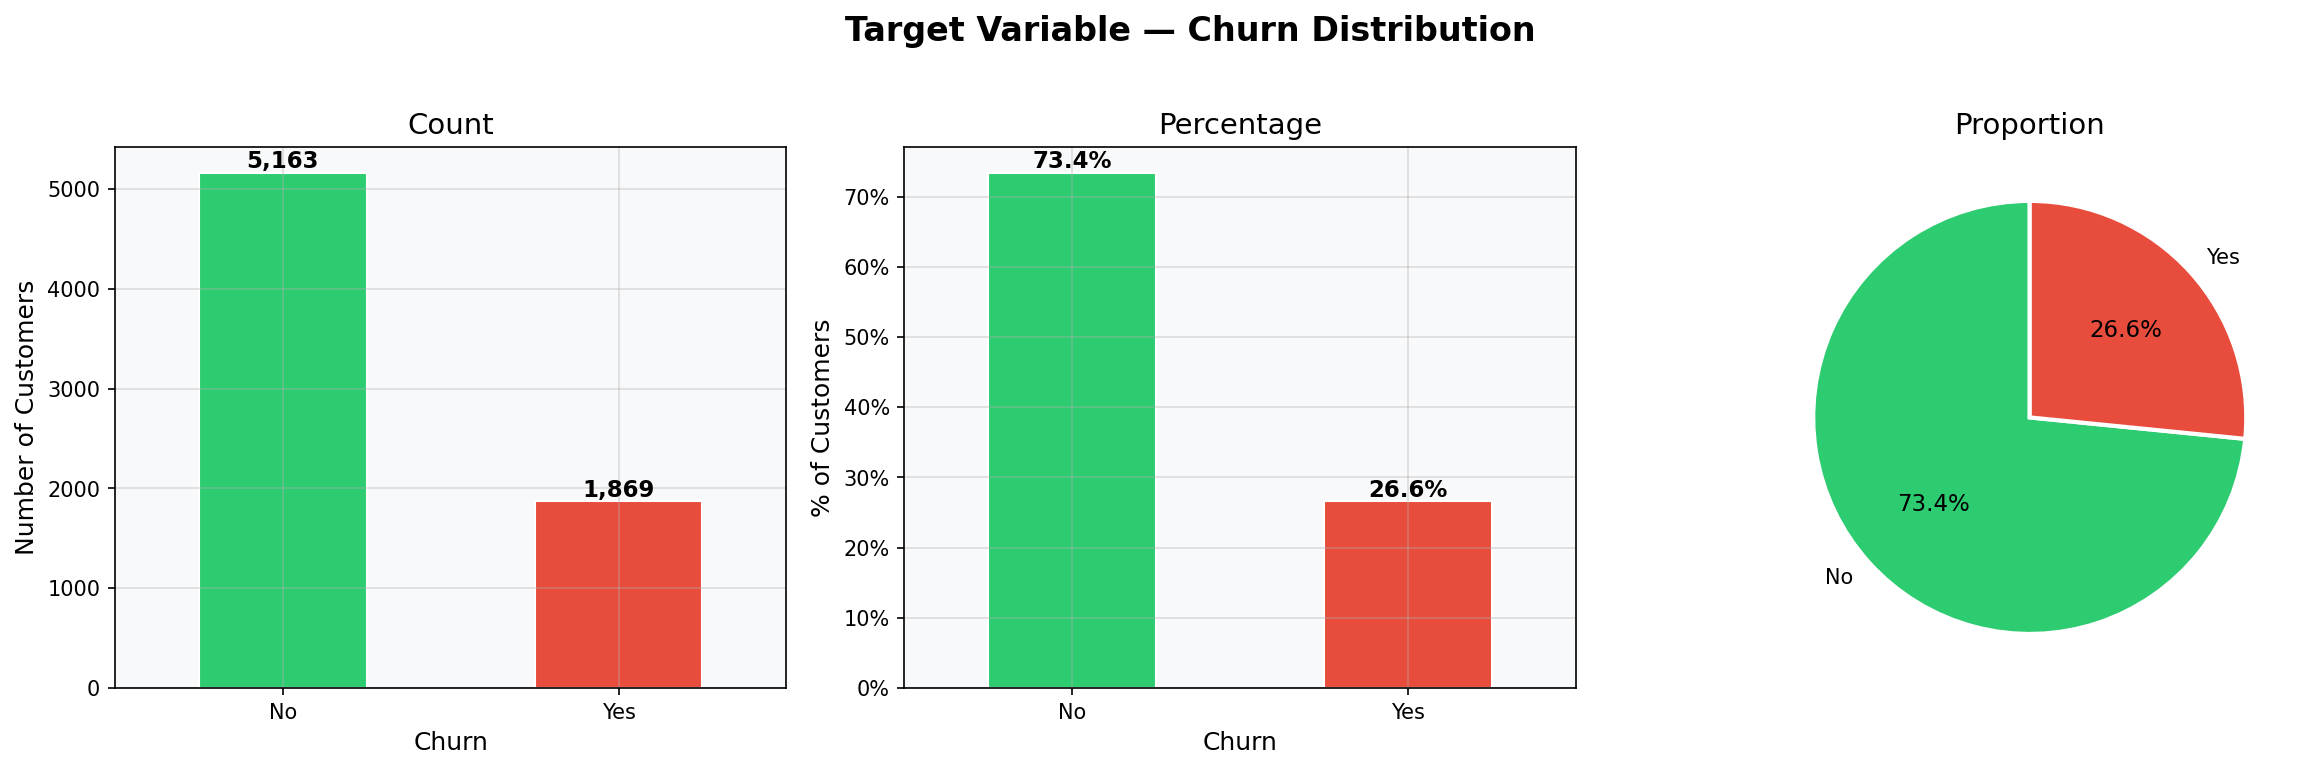

💾  Target distribution plot saved.

⚠️  Class imbalance ratio — No:Yes = 2.8:1


In [37]:
# ── 5.1  Churn class distribution ────────────────────────────────────────────
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({"Count": churn_counts, "Percentage": churn_pct.round(2)})
print("Target Variable (Churn) Distribution:")
display(target_summary)

# Save numeric summary
target_summary.to_csv(REPORT_DIR / "05_churn_distribution.csv")

# ── 5.2  Plot target distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Target Variable — Churn Distribution", fontsize=16, fontweight="bold", y=1.02)

COLORS = ["#2ecc71", "#e74c3c"]  # green=No churn, red=Churn

# Bar chart
churn_counts.plot(kind="bar", ax=axes[0], color=COLORS, edgecolor="white", width=0.5)
axes[0].set_title("Count")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=11, fontweight="bold")

# Percentage bar
churn_pct.plot(kind="bar", ax=axes[1], color=COLORS, edgecolor="white", width=0.5)
axes[1].set_title("Percentage")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("% of Customers")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=11, fontweight="bold")

# Pie chart
axes[2].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
            colors=COLORS, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[2].set_title("Proportion")

plt.tight_layout()
plt.savefig(IMG_DIR / "05_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Target distribution plot saved.")
print(f"\n⚠️  Class imbalance ratio — No:Yes = {churn_counts['No']/churn_counts['Yes']:.1f}:1")

## 6. Univariate Analysis

Examine each predictor independently, split by churn status.

In [38]:
# ── 6.1  Helper: save-aware countplot ────────────────────────────────────────
def churn_countplot(col, ax, df=df, hue="Churn", palette=None):
    """Bar chart for a categorical column split by Churn, with % annotations."""
    if palette is None:
        palette = {"No": "#2ecc71", "Yes": "#e74c3c"}
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue=hue, order=order,
                  palette=palette, edgecolor="white", ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Churn", fontsize=9)
    # Annotate bar heights
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{int(h)}",
                        (p.get_x() + p.get_width()/2, h),
                        ha="center", va="bottom", fontsize=7)

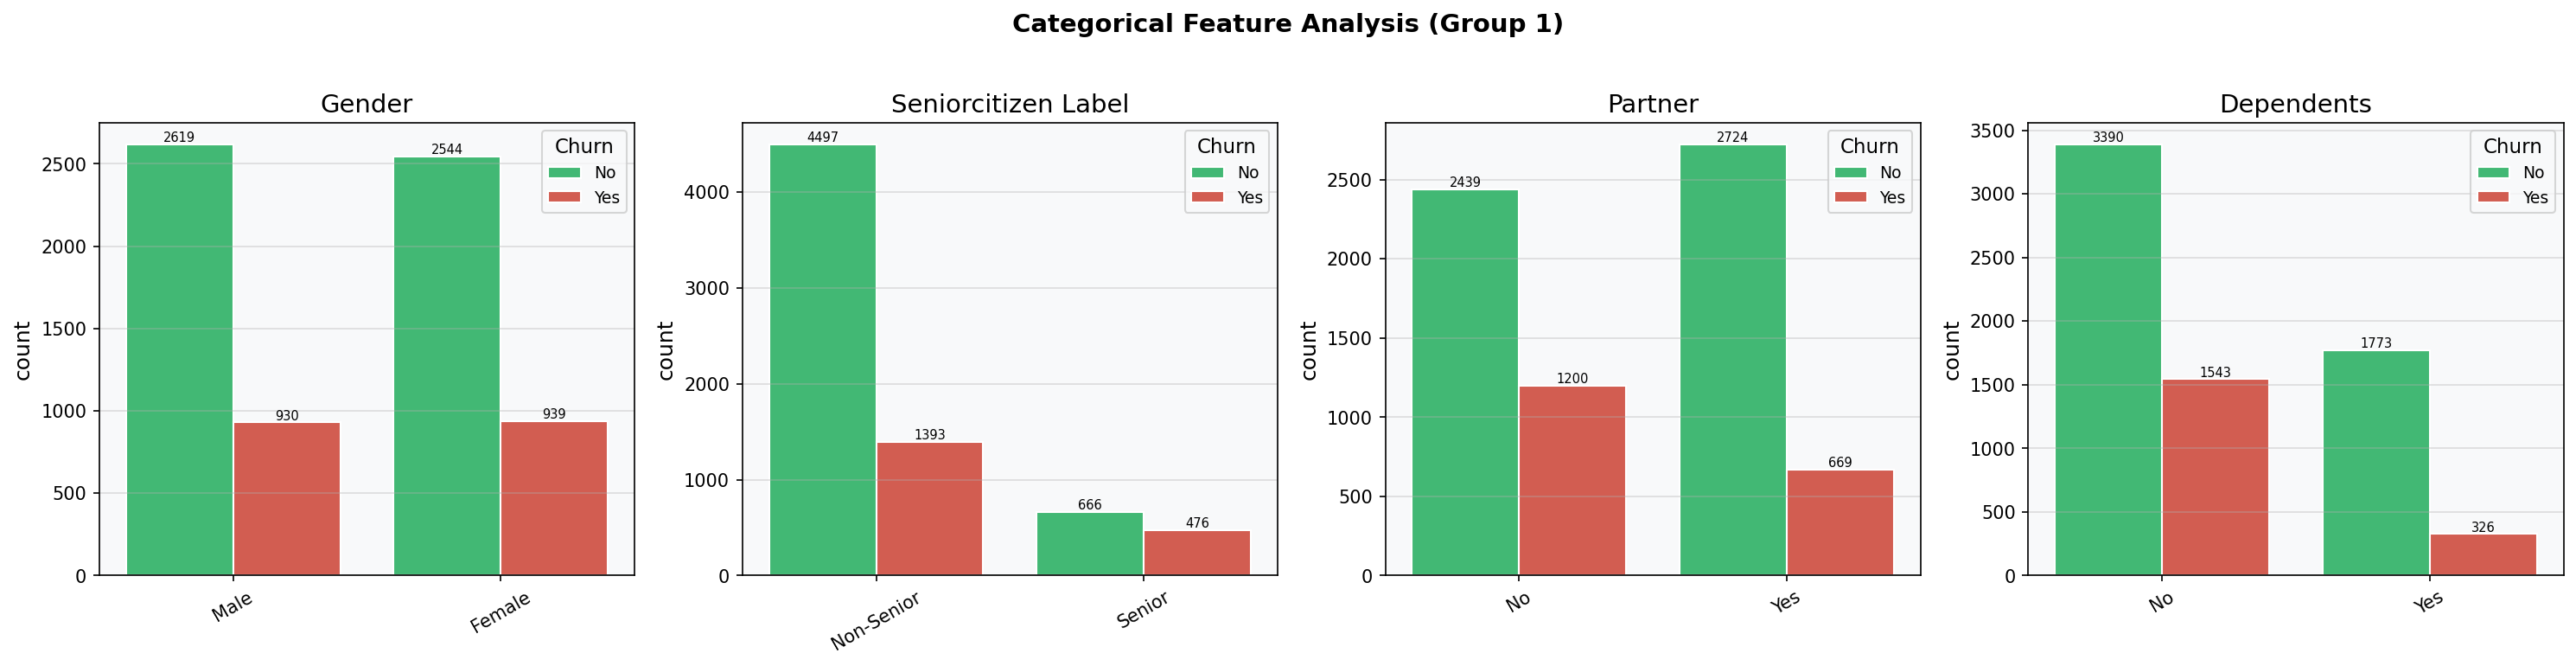

💾  Saved 06_univariate_cat_group1.png


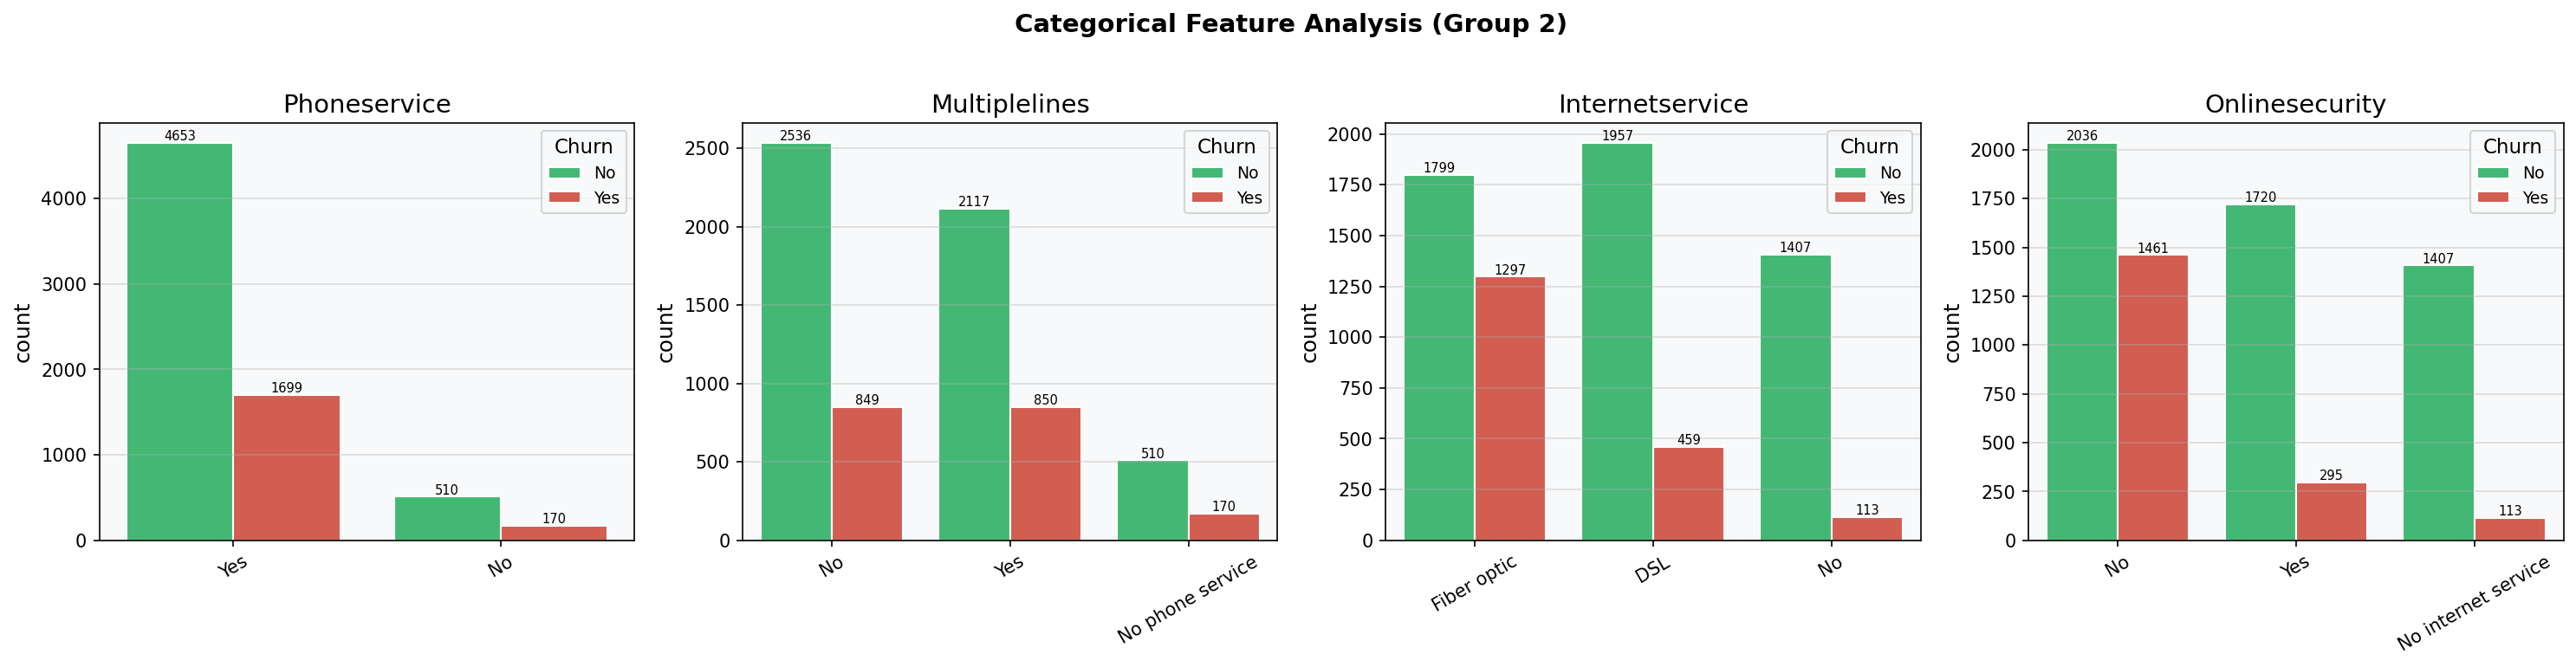

💾  Saved 06_univariate_cat_group2.png


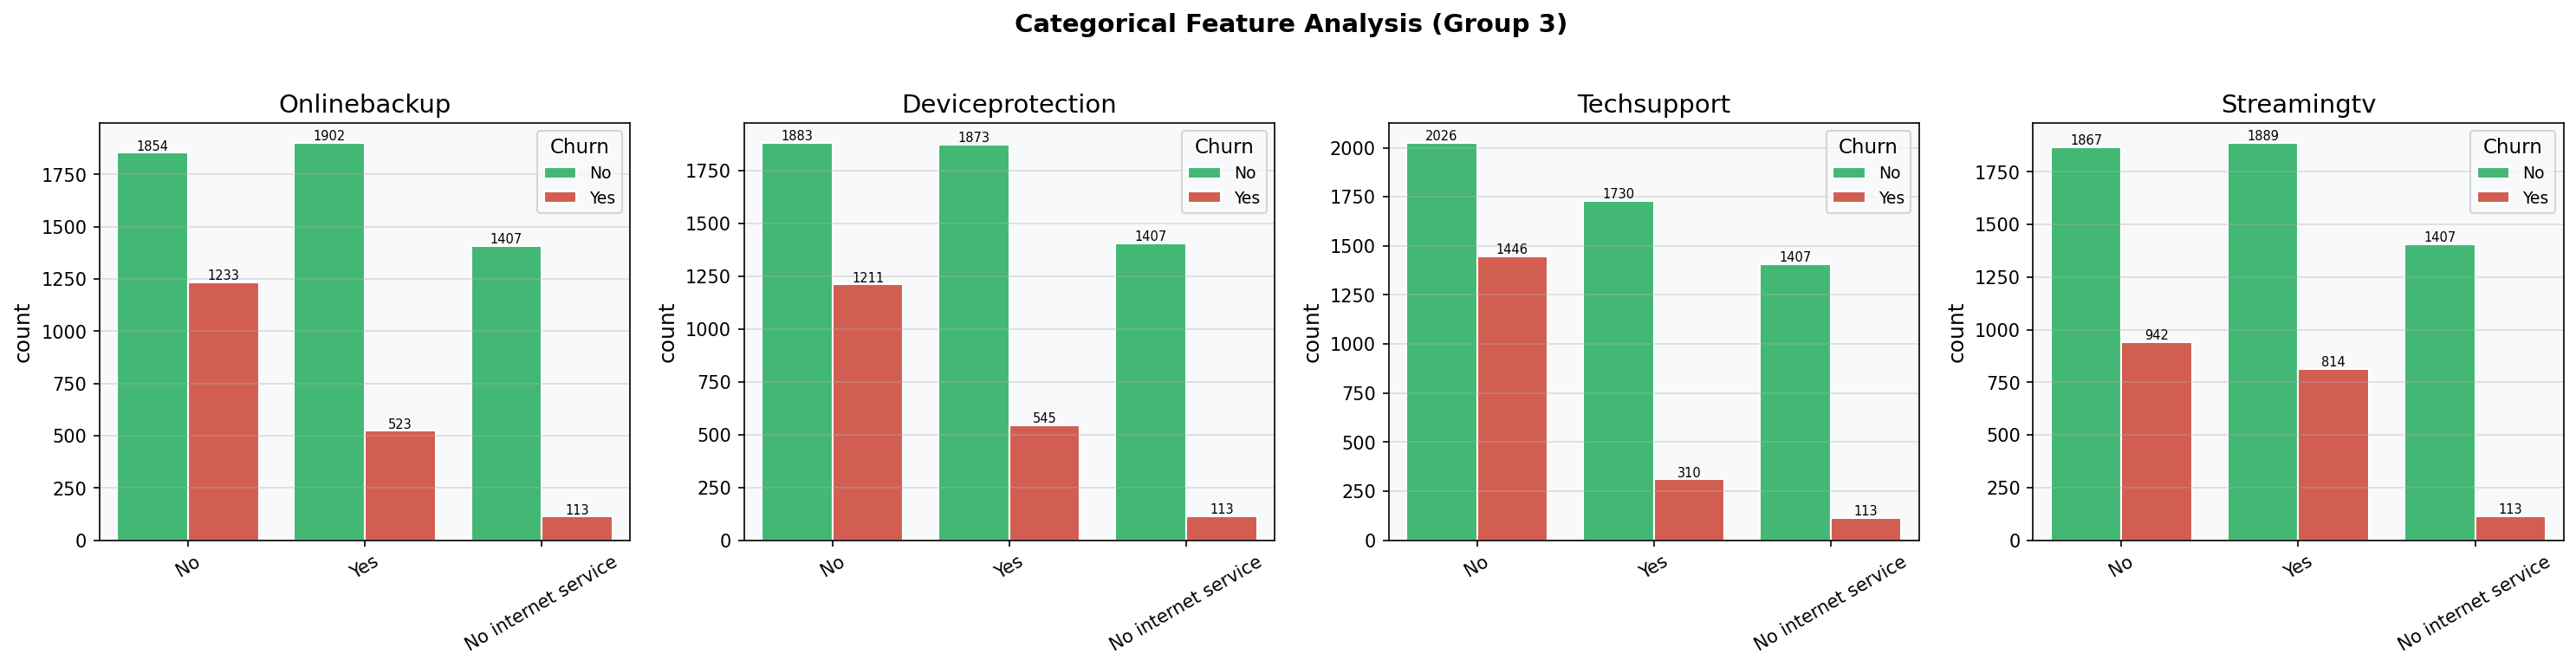

💾  Saved 06_univariate_cat_group3.png


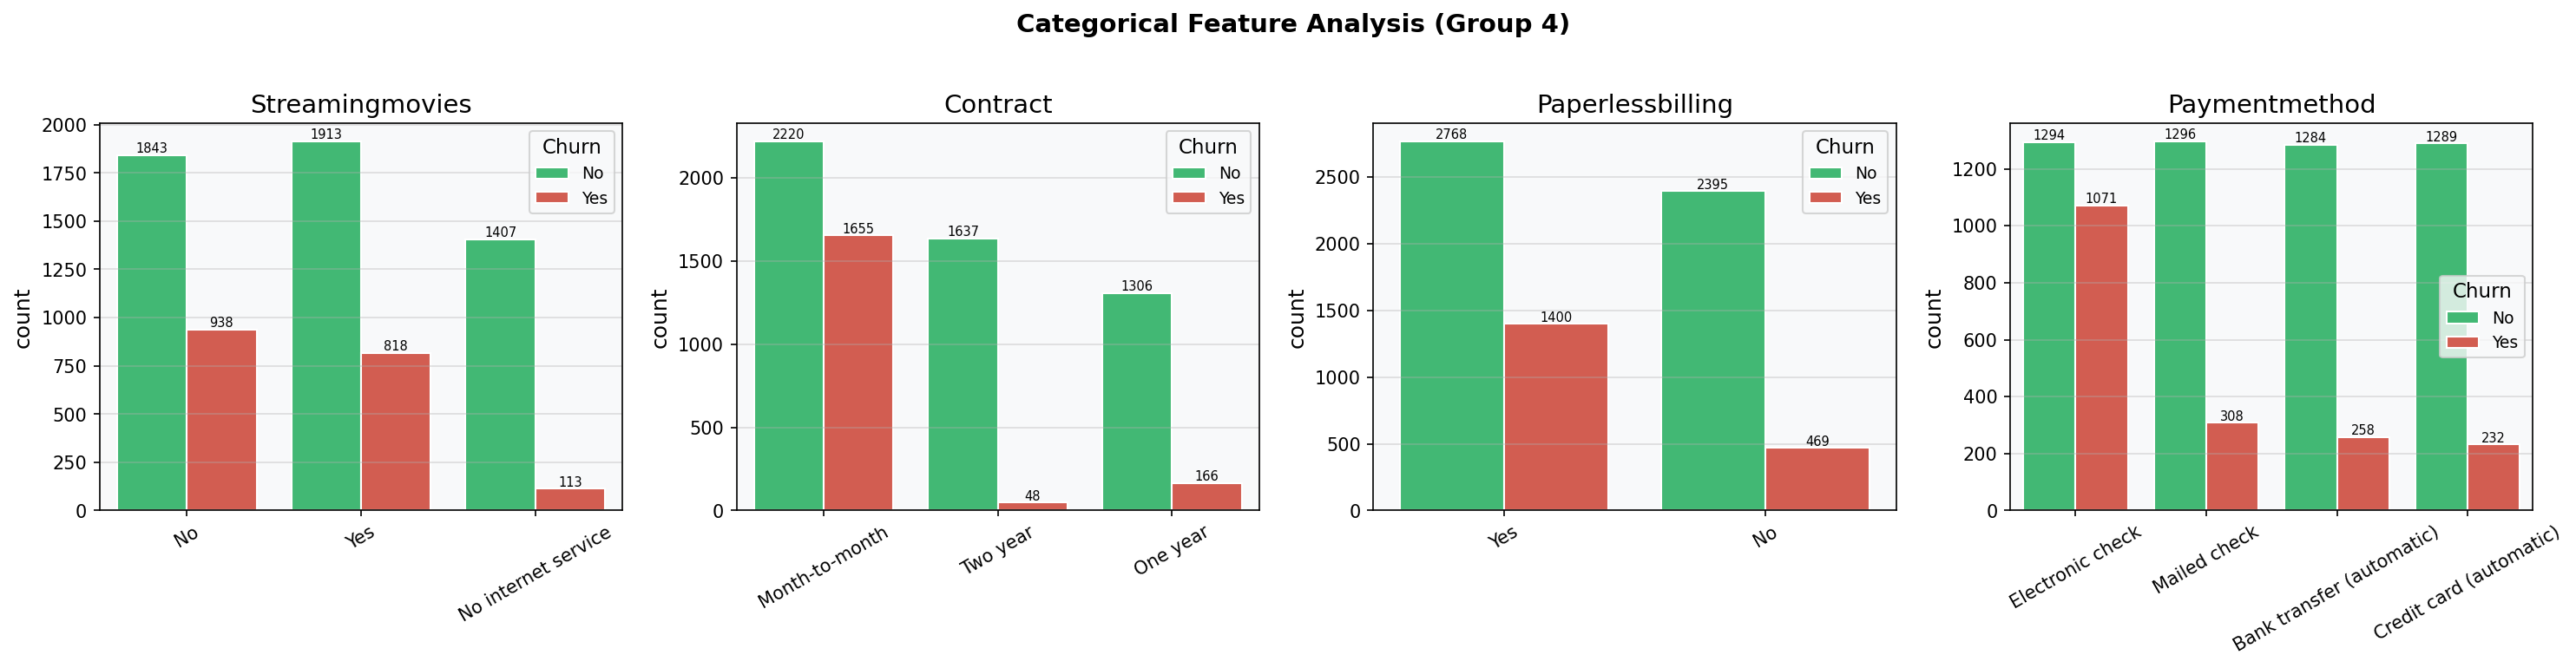

💾  Saved 06_univariate_cat_group4.png


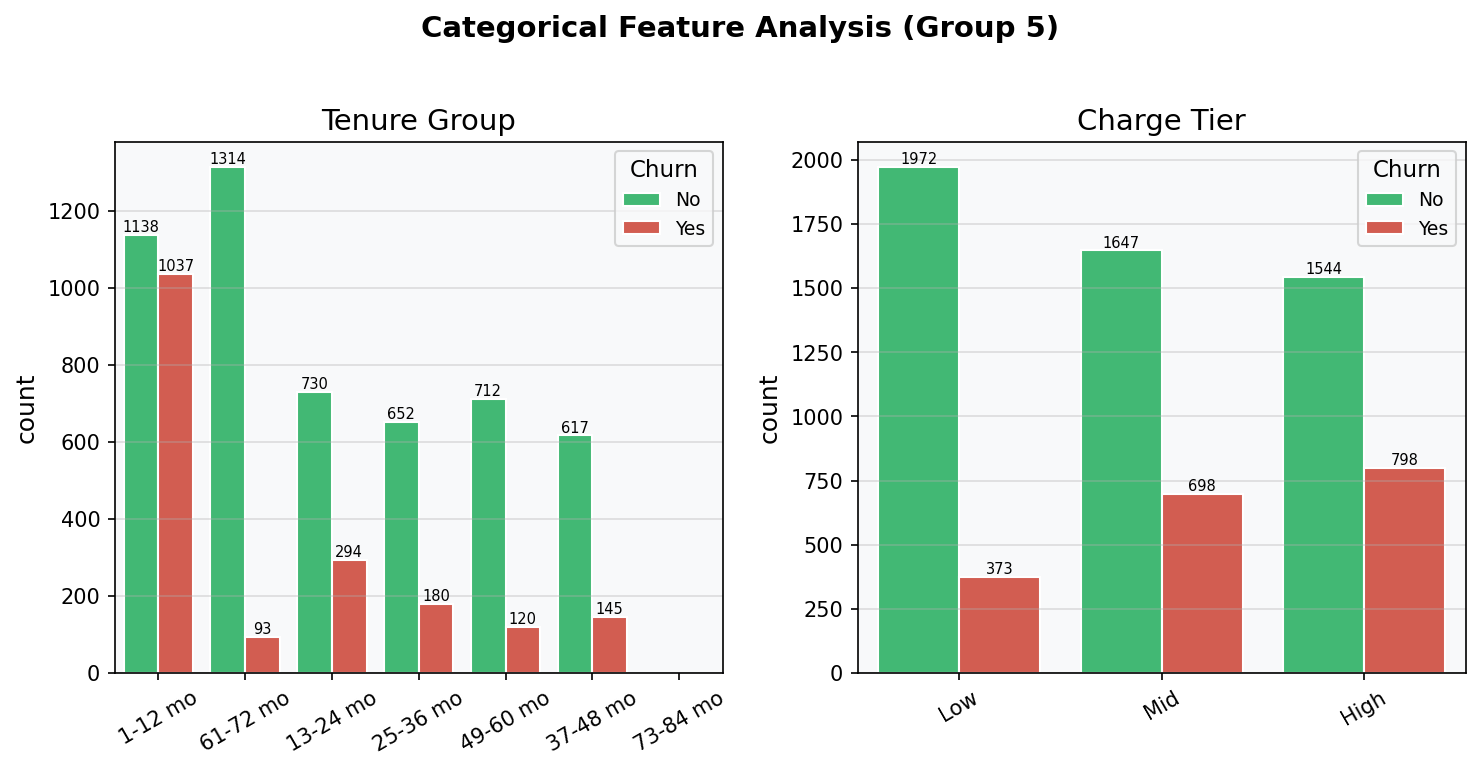

💾  Saved 06_univariate_cat_group5.png


In [39]:
# ── 6.2  Categorical univariate plots ────────────────────────────────────────
# These columns are categorical (or treated as such)
cat_cols = [
    "gender", "SeniorCitizen_Label", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
    "tenure_group", "charge_tier"
]

# Plot in groups of 4 per figure for readability
COLS_PER_FIG = 4
chunks = [cat_cols[i:i+COLS_PER_FIG] for i in range(0, len(cat_cols), COLS_PER_FIG)]

for fig_idx, chunk in enumerate(chunks, start=1):
    fig, axes = plt.subplots(1, len(chunk), figsize=(5*len(chunk), 5))
    if len(chunk) == 1:
        axes = [axes]  # ensure iterable
    fig.suptitle(f"Categorical Feature Analysis (Group {fig_idx})",
                 fontsize=14, fontweight="bold", y=1.02)
    for ax, col in zip(axes, chunk):
        churn_countplot(col, ax)
    plt.tight_layout()
    fname = IMG_DIR / f"06_univariate_cat_group{fig_idx}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾  Saved {fname.name}")

In [40]:
# ── 6.3  Churn rate per categorical feature ──────────────────────────────────
# A clean table showing churn % per category value — useful for business reports
churn_rate_tables = {}

for col in cat_cols:
    if col in df.columns:
        tbl = (
            df.groupby(col)["Churn_Flag"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "churn_rate", "count": "n_customers"})
            .sort_values("churn_rate", ascending=False)
        )
        tbl["churn_rate_pct"] = (tbl["churn_rate"] * 100).round(2)
        churn_rate_tables[col] = tbl

# Print a summary of top churning categories across features
print("Top Churn Rate by Category (Top 2 per feature):")
print("=" * 60)
for col, tbl in churn_rate_tables.items():
    top = tbl.head(2)
    for idx, row in top.iterrows():
        print(f"  [{col}] {idx}: {row['churn_rate_pct']:.1f}%  (n={int(row['n_customers']):,})")

# Save all churn rate tables
all_churn_rates = pd.concat(
    [tbl.assign(feature=col).reset_index().rename(columns={col: "category"})
     for col, tbl in churn_rate_tables.items()]
)
all_churn_rates.to_csv(REPORT_DIR / "06_churn_rate_by_category.csv", index=False)
print(f"\n💾  Churn rate table saved → {REPORT_DIR / '06_churn_rate_by_category.csv'}")

Top Churn Rate by Category (Top 2 per feature):
  [gender] Female: 27.0%  (n=3,483)
  [gender] Male: 26.2%  (n=3,549)
  [SeniorCitizen_Label] Senior: 41.7%  (n=1,142)
  [SeniorCitizen_Label] Non-Senior: 23.6%  (n=5,890)
  [Partner] No: 33.0%  (n=3,639)
  [Partner] Yes: 19.7%  (n=3,393)
  [Dependents] No: 31.3%  (n=4,933)
  [Dependents] Yes: 15.5%  (n=2,099)
  [PhoneService] Yes: 26.8%  (n=6,352)
  [PhoneService] No: 25.0%  (n=680)
  [MultipleLines] Yes: 28.6%  (n=2,967)
  [MultipleLines] No: 25.1%  (n=3,385)
  [InternetService] Fiber optic: 41.9%  (n=3,096)
  [InternetService] DSL: 19.0%  (n=2,416)
  [OnlineSecurity] No: 41.8%  (n=3,497)
  [OnlineSecurity] Yes: 14.6%  (n=2,015)
  [OnlineBackup] No: 39.9%  (n=3,087)
  [OnlineBackup] Yes: 21.6%  (n=2,425)
  [DeviceProtection] No: 39.1%  (n=3,094)
  [DeviceProtection] Yes: 22.5%  (n=2,418)
  [TechSupport] No: 41.6%  (n=3,472)
  [TechSupport] Yes: 15.2%  (n=2,040)
  [StreamingTV] No: 33.5%  (n=2,809)
  [StreamingTV] Yes: 30.1%  (n=2,703)
 

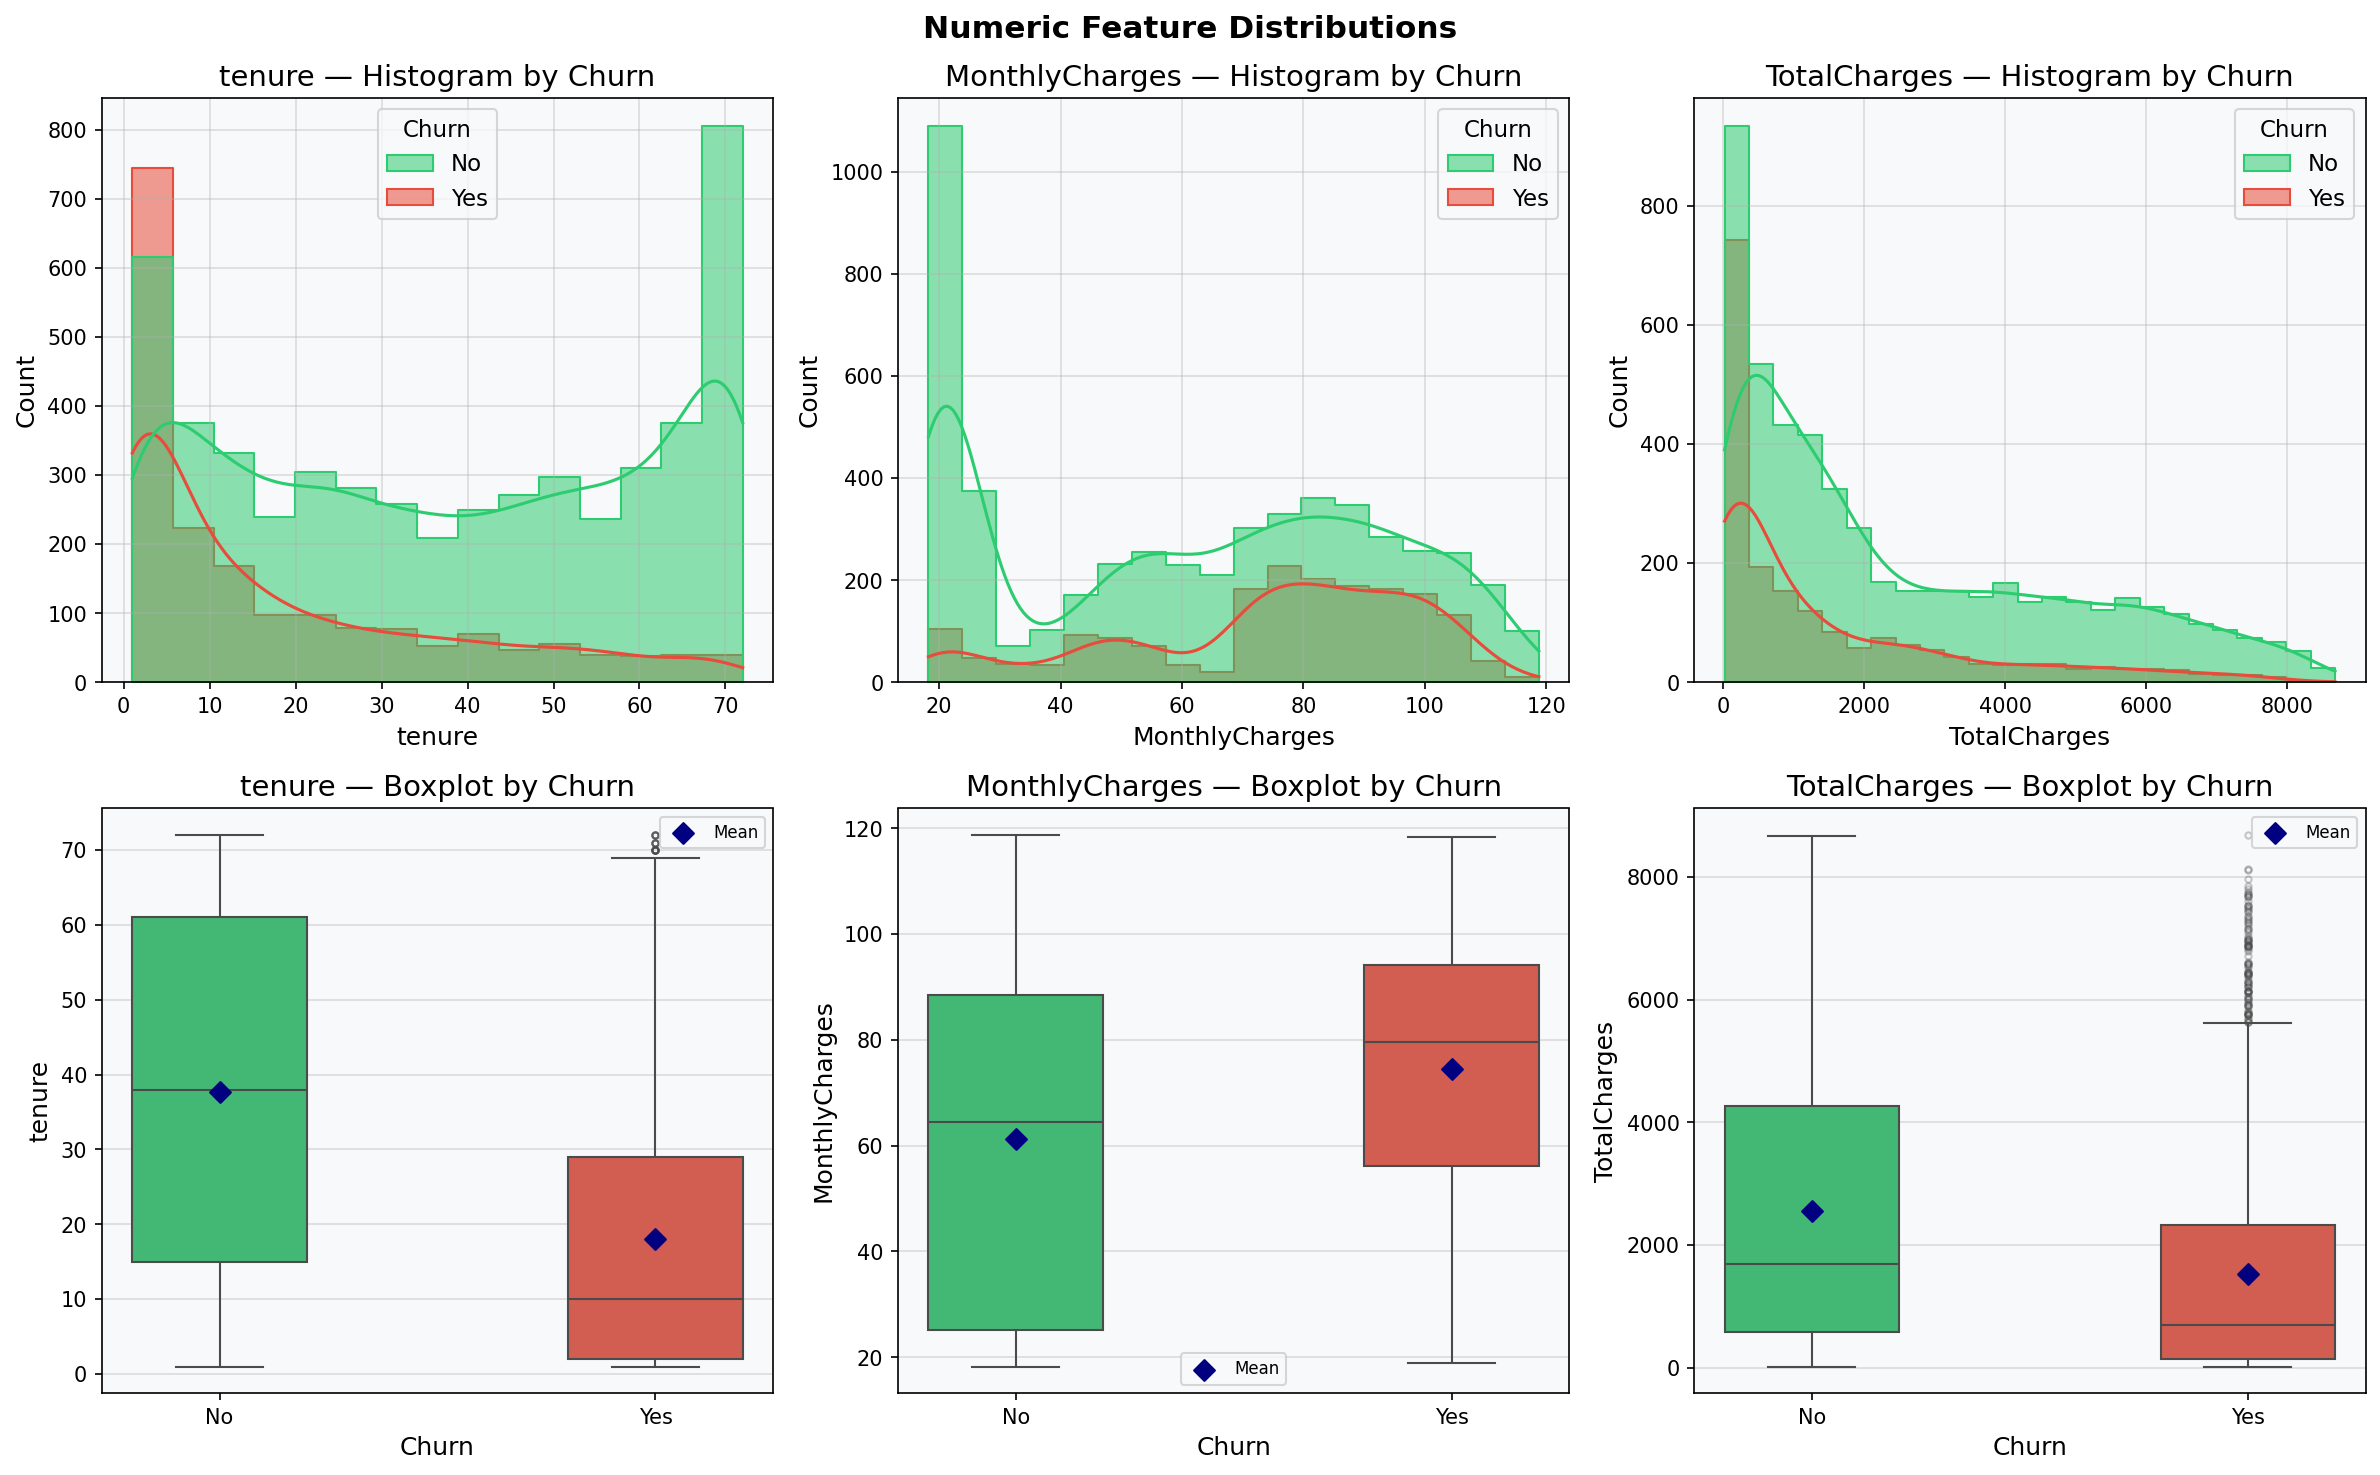

💾  Numeric distribution plots saved.


In [41]:
# ── 6.4  Numeric univariate: distributions ───────────────────────────────────
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Numeric Feature Distributions", fontsize=15, fontweight="bold")

for i, col in enumerate(num_cols):
    # Histogram + KDE (top row)
    ax_hist = axes[0, i]
    sns.histplot(data=df, x=col, hue="Churn", kde=True,
                 palette={"No": "#2ecc71", "Yes": "#e74c3c"},
                 alpha=0.55, element="step", ax=ax_hist)
    ax_hist.set_title(f"{col} — Histogram by Churn")
    ax_hist.set_xlabel(col)

    # Box plot (bottom row)
    ax_box = axes[1, i]
    sns.boxplot(data=df, x="Churn", y=col,
                palette={"No": "#2ecc71", "Yes": "#e74c3c"},
                width=0.4, ax=ax_box, flierprops=dict(marker=".", alpha=0.3))
    # Overlay mean points
    means = df.groupby("Churn")[col].mean()
    ax_box.scatter(x=[0, 1], y=means.values, marker="D", color="navy",
                   zorder=5, s=50, label="Mean")
    ax_box.set_title(f"{col} — Boxplot by Churn")
    ax_box.legend(fontsize=8)

plt.tight_layout()
plt.savefig(IMG_DIR / "06_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Numeric distribution plots saved.")

In [42]:
# ── 6.5  Statistical test: mean difference (churned vs. not churned) ─────────
# Two-sample Welch's t-test (does NOT assume equal variance)
print("Two-Sample Welch's T-Test — Numeric Features vs Churn")
print("=" * 60)

stat_results = []
for col in num_cols:
    grp_no  = df.loc[df["Churn_Flag"]==0, col].dropna()
    grp_yes = df.loc[df["Churn_Flag"]==1, col].dropna()
    t_stat, p_val = stats.ttest_ind(grp_no, grp_yes, equal_var=False)
    cohend = (grp_yes.mean() - grp_no.mean()) / np.sqrt(
        (grp_yes.std()**2 + grp_no.std()**2) / 2
    )
    stat_results.append({
        "feature": col,
        "mean_no_churn":  round(grp_no.mean(), 2),
        "mean_churn":     round(grp_yes.mean(), 2),
        "t_statistic":    round(t_stat, 4),
        "p_value":        round(p_val, 6),
        "cohens_d":       round(cohend, 4),
        "significant":    "Yes" if p_val < 0.05 else "No"
    })

stat_df = pd.DataFrame(stat_results)
display(stat_df)
stat_df.to_csv(REPORT_DIR / "06_ttest_results.csv", index=False)
print("💾  T-test results saved.")

Two-Sample Welch's T-Test — Numeric Features vs Churn


,feature,mean_no_churn,mean_churn,t_statistic,p_value,cohens_d,significant
0,tenure,37.6500,17.9800,34.9719,0.0000,-0.8973,Yes
1,MonthlyCharges,61.3100,74.4400,-18.3409,0.0000,0.4680,Yes
2,TotalCharges,2555.3400,1531.8000,18.8008,0.0000,-0.4825,Yes


💾  T-test results saved.


## 7. Bivariate Analysis

Deep-dive into the most impactful feature pairs vs churn.

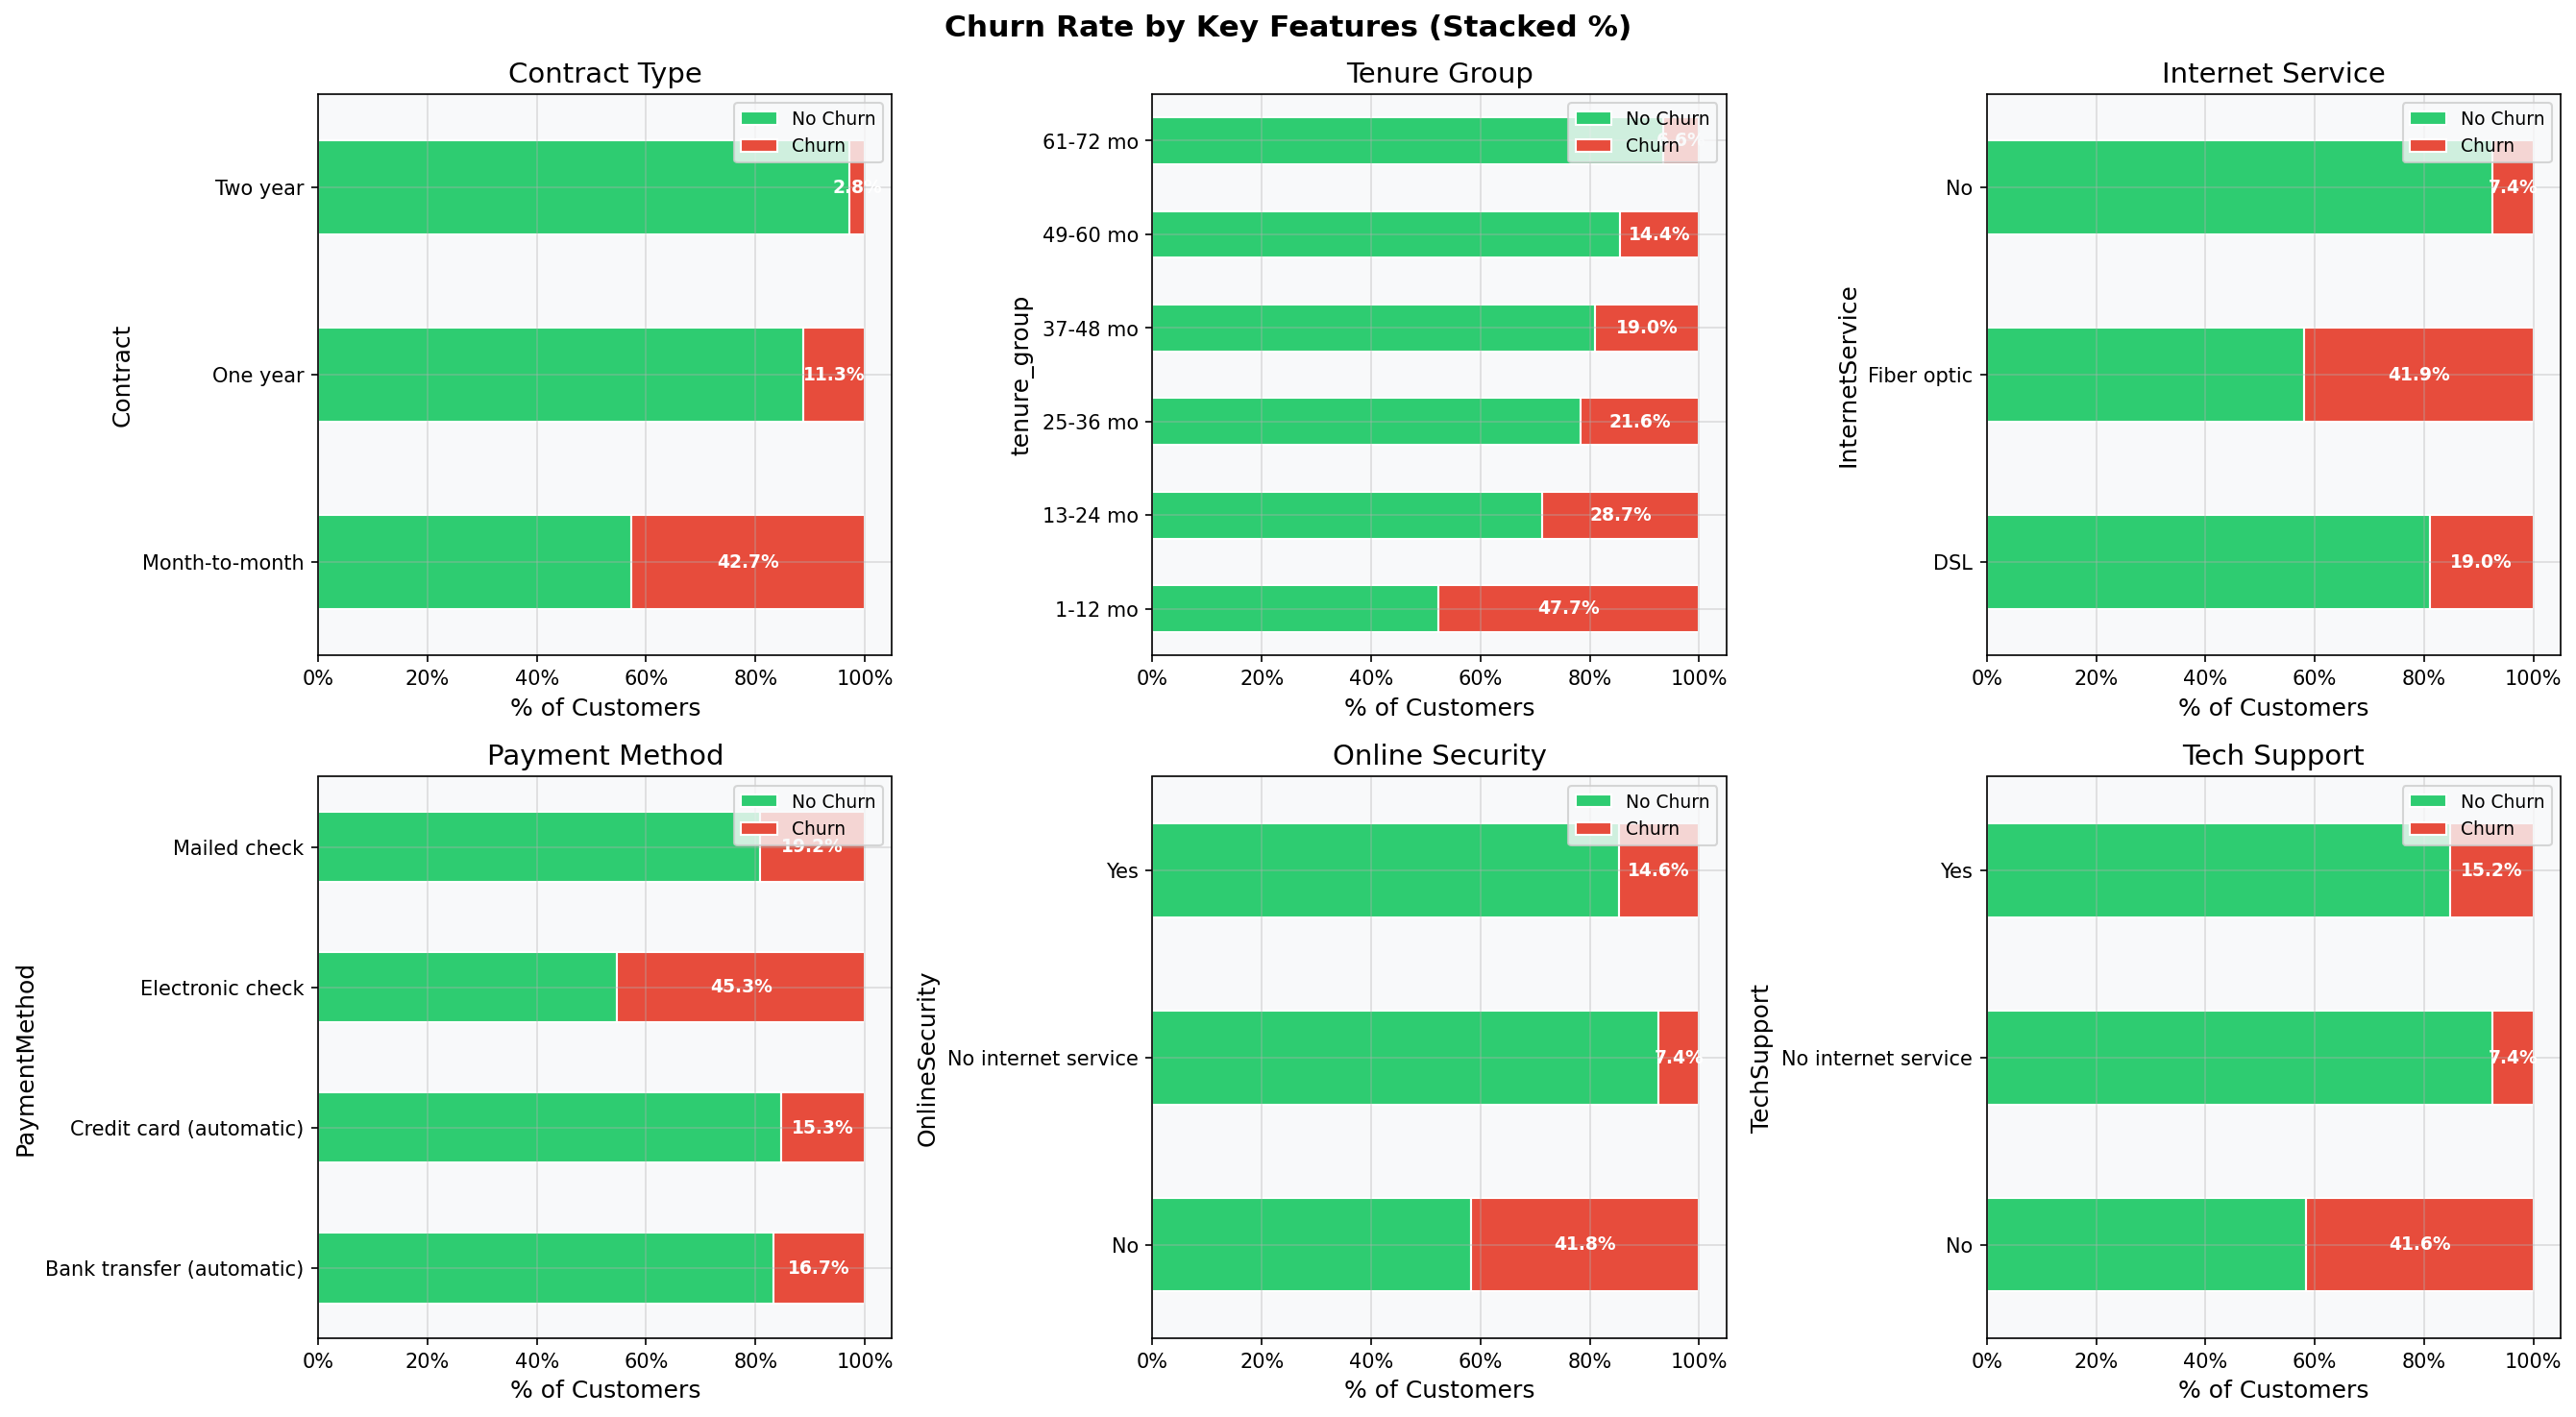

💾  Bivariate stacked % bars saved.


In [43]:
# ── 7.1  Stacked % bar chart — Contract × Churn ──────────────────────────────
def stacked_pct_bar(col, title, ax, df=df):
    """Horizontal stacked percentage bar chart of a categorical col vs Churn."""
    ct  = pd.crosstab(df[col], df["Churn"])
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    pct[["No", "Yes"]].plot(kind="barh", stacked=True, ax=ax,
                             color=["#2ecc71", "#e74c3c"], edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("% of Customers")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(["No Churn", "Churn"], loc="upper right", fontsize=9)
    # Annotate churn %
    for i, (idx, row) in enumerate(pct.iterrows()):
        ax.text(row["No"] + row["Yes"]/2, i,
                f"{row['Yes']:.1f}%", va="center", ha="center",
                fontsize=9, color="white", fontweight="bold")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Churn Rate by Key Features (Stacked %)",
             fontsize=15, fontweight="bold")

stacked_pct_bar("Contract",        "Contract Type",       axes[0,0])
stacked_pct_bar("tenure_group",    "Tenure Group",        axes[0,1])
stacked_pct_bar("InternetService", "Internet Service",    axes[0,2])
stacked_pct_bar("PaymentMethod",   "Payment Method",      axes[1,0])
stacked_pct_bar("OnlineSecurity",  "Online Security",     axes[1,1])
stacked_pct_bar("TechSupport",     "Tech Support",        axes[1,2])

plt.tight_layout()
plt.savefig(IMG_DIR / "07_bivariate_stacked_pct.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Bivariate stacked % bars saved.")

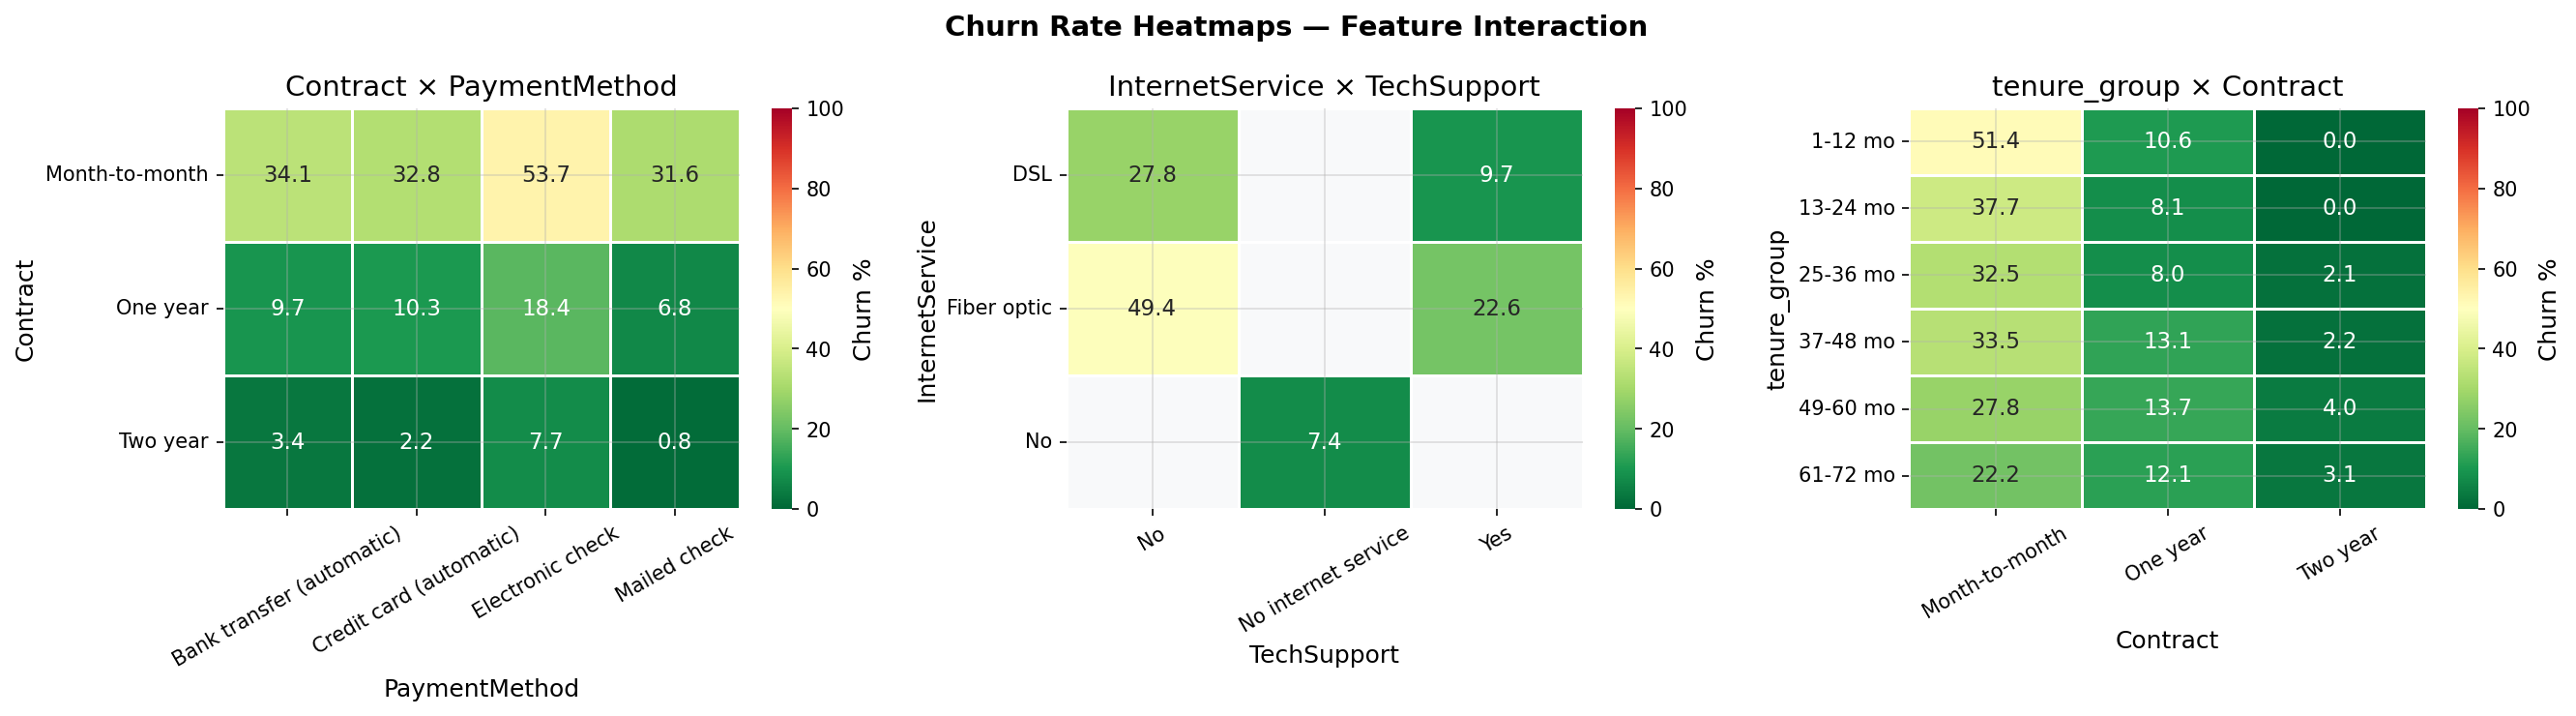

💾  Crosstab heatmaps saved.


In [44]:
# ── 7.2  Crosstab heatmaps for top categorical pairs ─────────────────────────
pairs = [
    ("Contract",       "PaymentMethod"),
    ("InternetService","TechSupport"),
    ("tenure_group",   "Contract"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Churn Rate Heatmaps — Feature Interaction",
             fontsize=14, fontweight="bold")

for ax, (col_x, col_y) in zip(axes, pairs):
    pivot = df.pivot_table(values="Churn_Flag", index=col_x,
                           columns=col_y, aggfunc="mean") * 100
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Churn %"},
                vmin=0, vmax=100)
    ax.set_title(f"{col_x} × {col_y}")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(IMG_DIR / "07_bivariate_crosstab_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Crosstab heatmaps saved.")

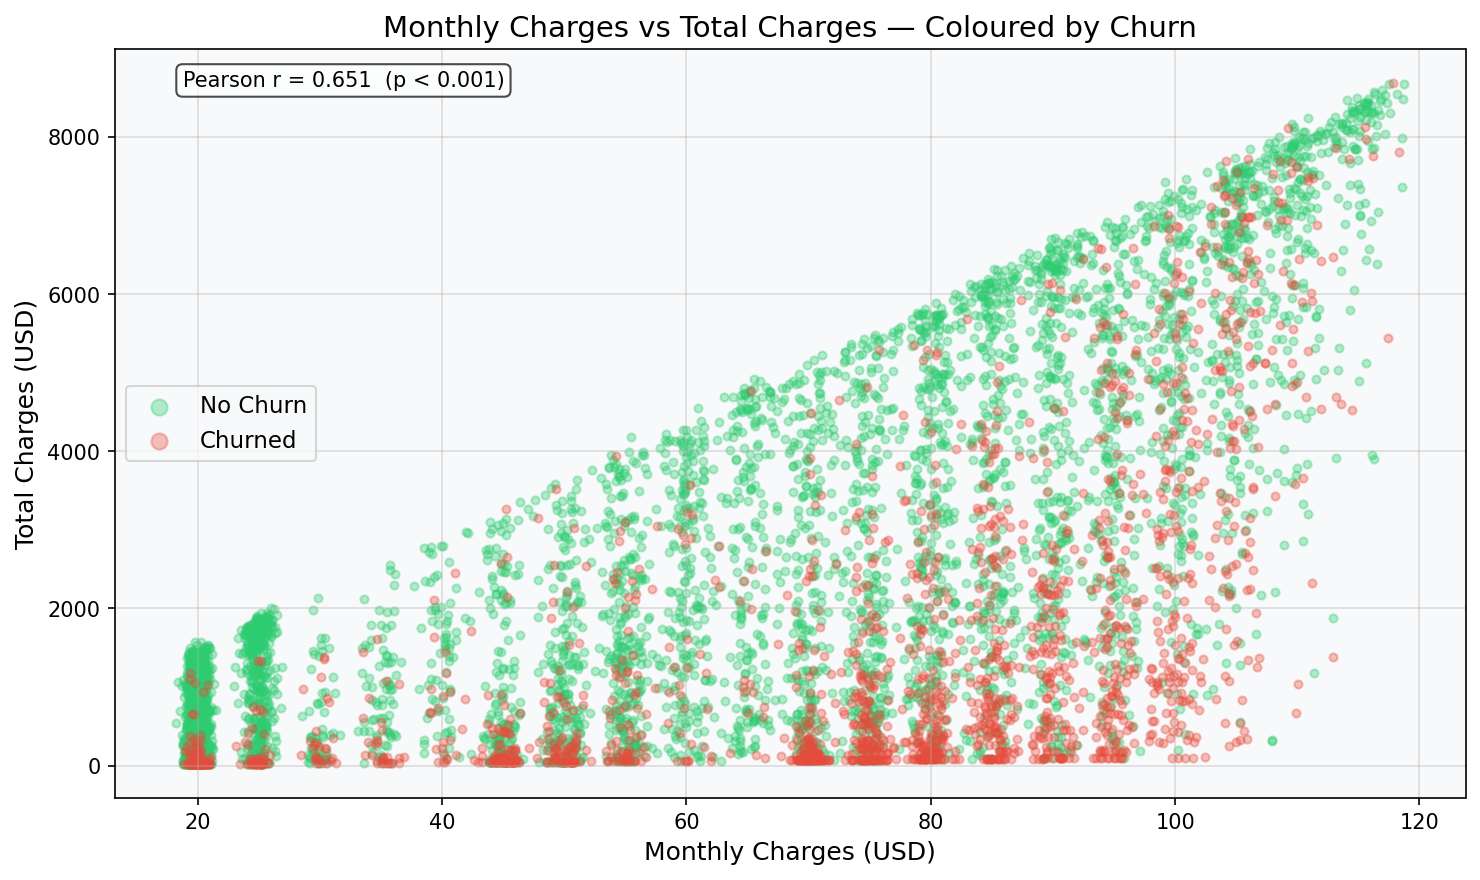

💾  Scatter saved. Pearson r = 0.651


In [45]:
# ── 7.3  Scatter: Monthly Charges vs Total Charges coloured by Churn ─────────
fig, ax = plt.subplots(figsize=(10, 6))

for churn_val, label, color in [(0, "No Churn", "#2ecc71"), (1, "Churned", "#e74c3c")]:
    sub = df[df["Churn_Flag"] == churn_val]
    ax.scatter(sub["MonthlyCharges"], sub["TotalCharges"],
               alpha=0.35, s=15, c=color, label=label, rasterized=True)

# Pearson r annotation
r, p = stats.pearsonr(df["MonthlyCharges"], df["TotalCharges"])
ax.text(0.05, 0.95, f"Pearson r = {r:.3f}  (p < 0.001)",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

ax.set_xlabel("Monthly Charges (USD)")
ax.set_ylabel("Total Charges (USD)")
ax.set_title("Monthly Charges vs Total Charges — Coloured by Churn")
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig(IMG_DIR / "07_scatter_charges_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"💾  Scatter saved. Pearson r = {r:.3f}")

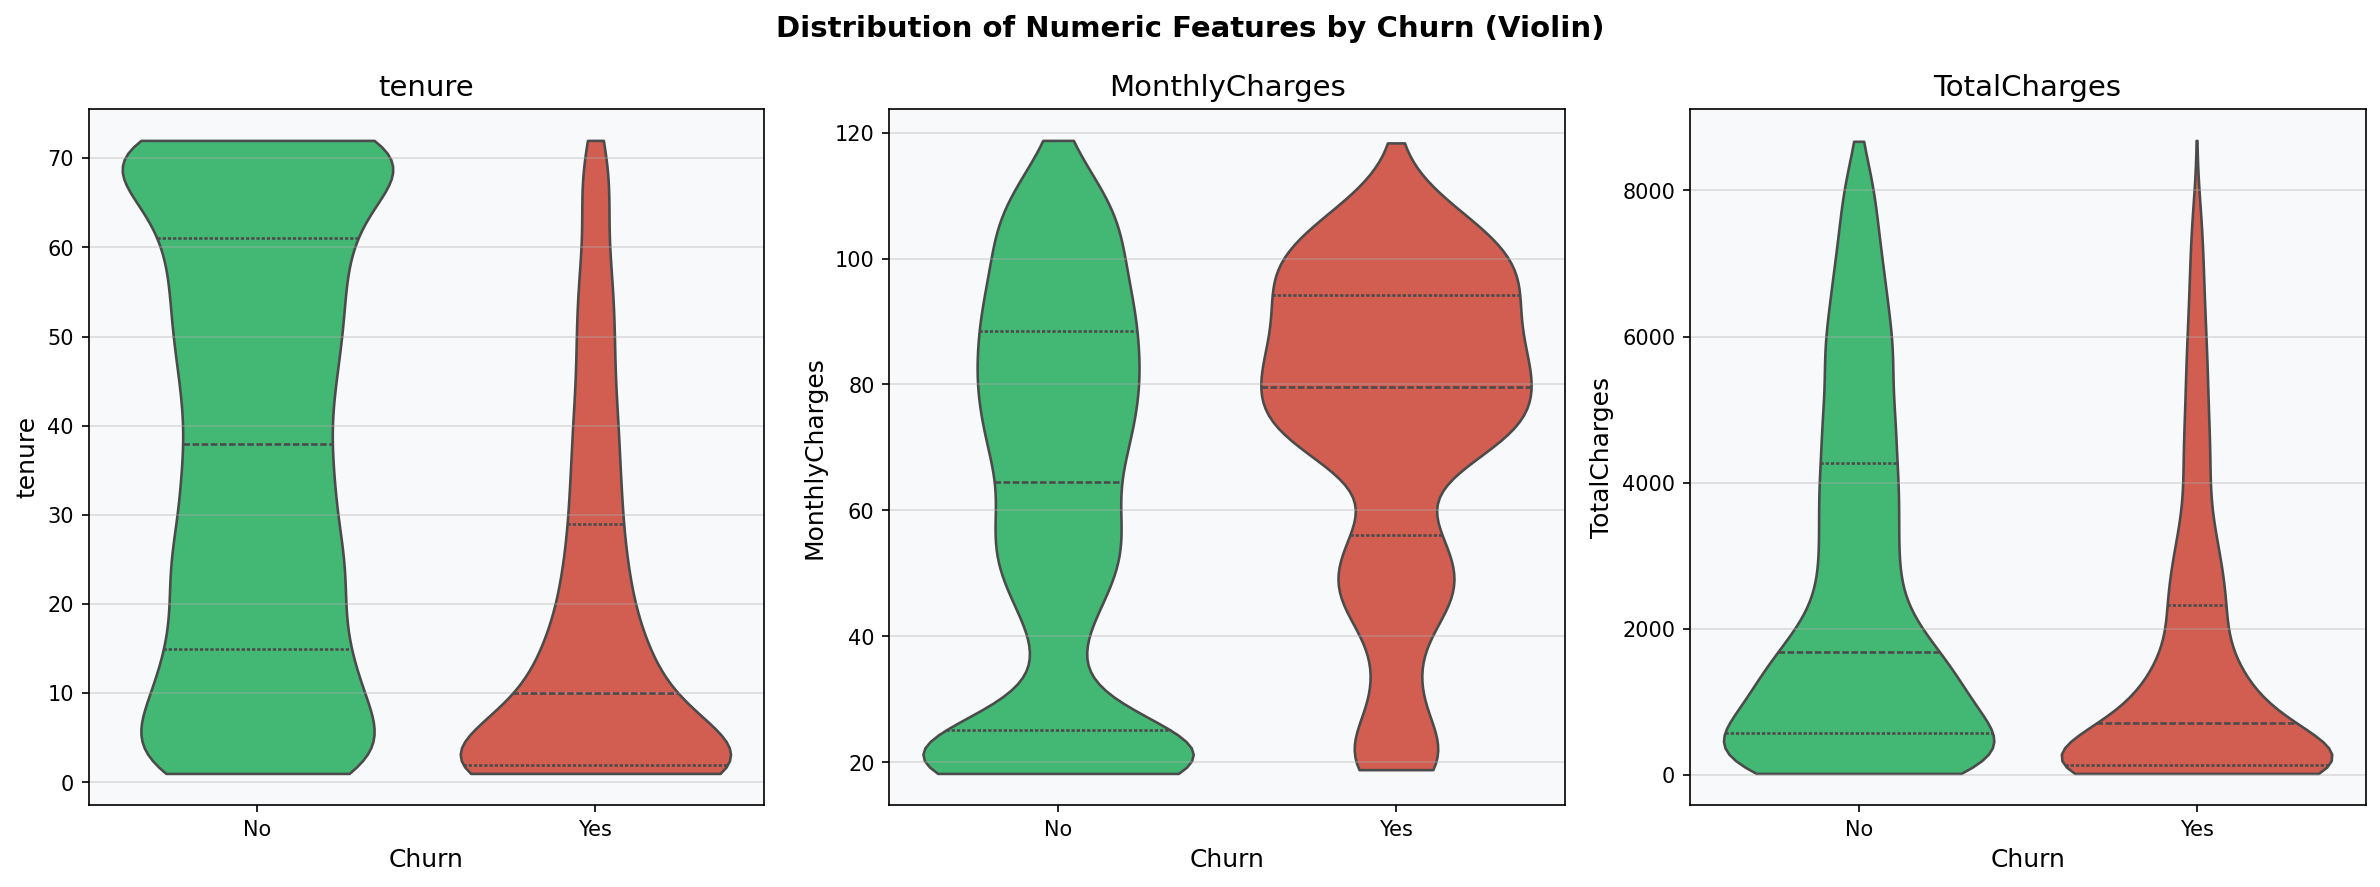

💾  Violin plots saved.


In [46]:
# ── 7.4  Violin plots: numeric features by churn ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Distribution of Numeric Features by Churn (Violin)",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.violinplot(data=df, x="Churn", y=col,
                   palette={"No": "#2ecc71", "Yes": "#e74c3c"},
                   inner="quartile", ax=ax, cut=0)
    ax.set_title(col)
    ax.set_xlabel("Churn")

plt.tight_layout()
plt.savefig(IMG_DIR / "07_violin_numeric_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Violin plots saved.")

## 8. Correlation & Heatmap Analysis

In [47]:
# ── 8.1  One-hot encode for numeric correlation ───────────────────────────────
# Encode all object columns to enable Pearson correlation
df_enc = pd.get_dummies(df.drop(columns=["customerID","Churn",
                                          "SeniorCitizen_Label",
                                          "charge_tier","ltv_proxy"]),
                        drop_first=True)

print(f"Encoded dataframe shape: {df_enc.shape}")
df_enc.to_csv(DATA_DIR / "08_encoded_data.csv", index=False)
print("💾  Encoded dataset saved.")

Encoded dataframe shape: (7032, 37)
💾  Encoded dataset saved.


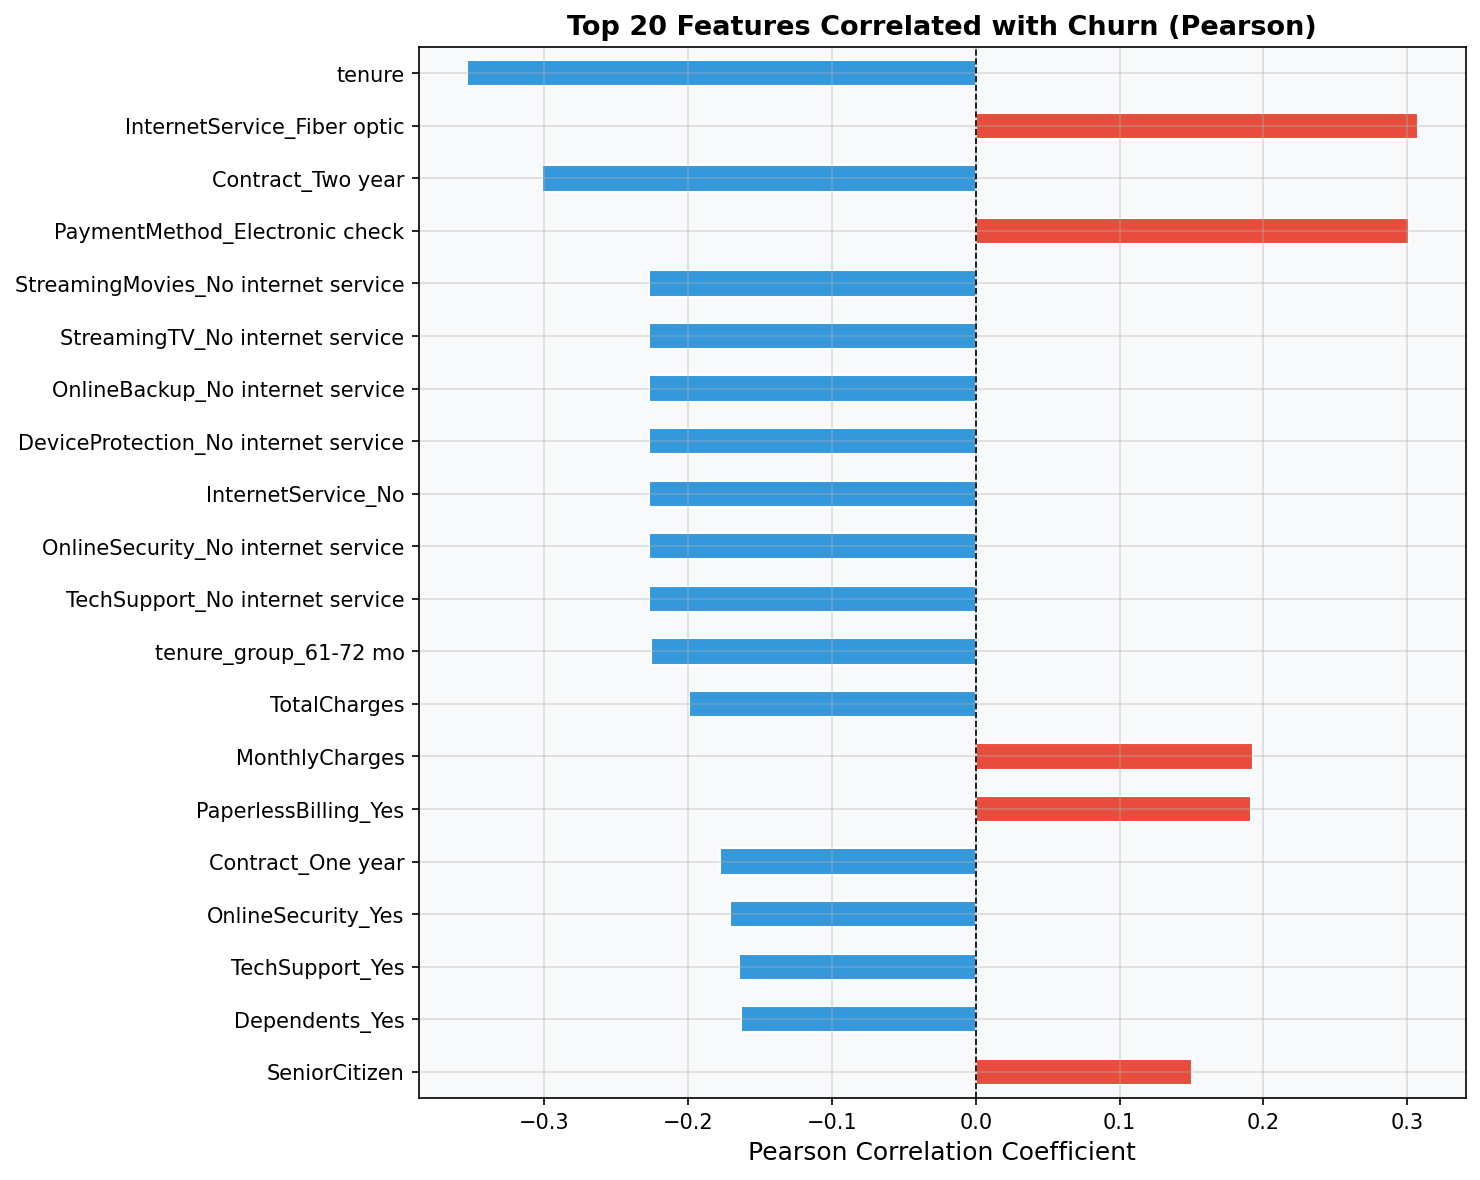

💾  Correlation bar chart + CSV saved.


In [48]:
# ── 8.2  Top predictors by Pearson correlation with Churn_Flag ───────────────
churn_corr = (
    df_enc.corr()["Churn_Flag"]
    .drop("Churn_Flag")
    .sort_values(key=abs, ascending=False)
)

# Visualise top 20 correlated features
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in churn_corr.head(20).values]
churn_corr.head(20).plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Top 20 Features Correlated with Churn (Pearson)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(IMG_DIR / "08_churn_correlation_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Save correlation values
churn_corr.reset_index().rename(columns={"index": "feature", "Churn_Flag": "pearson_r"}).to_csv(
    REPORT_DIR / "08_churn_correlations.csv", index=False
)
print("💾  Correlation bar chart + CSV saved.")

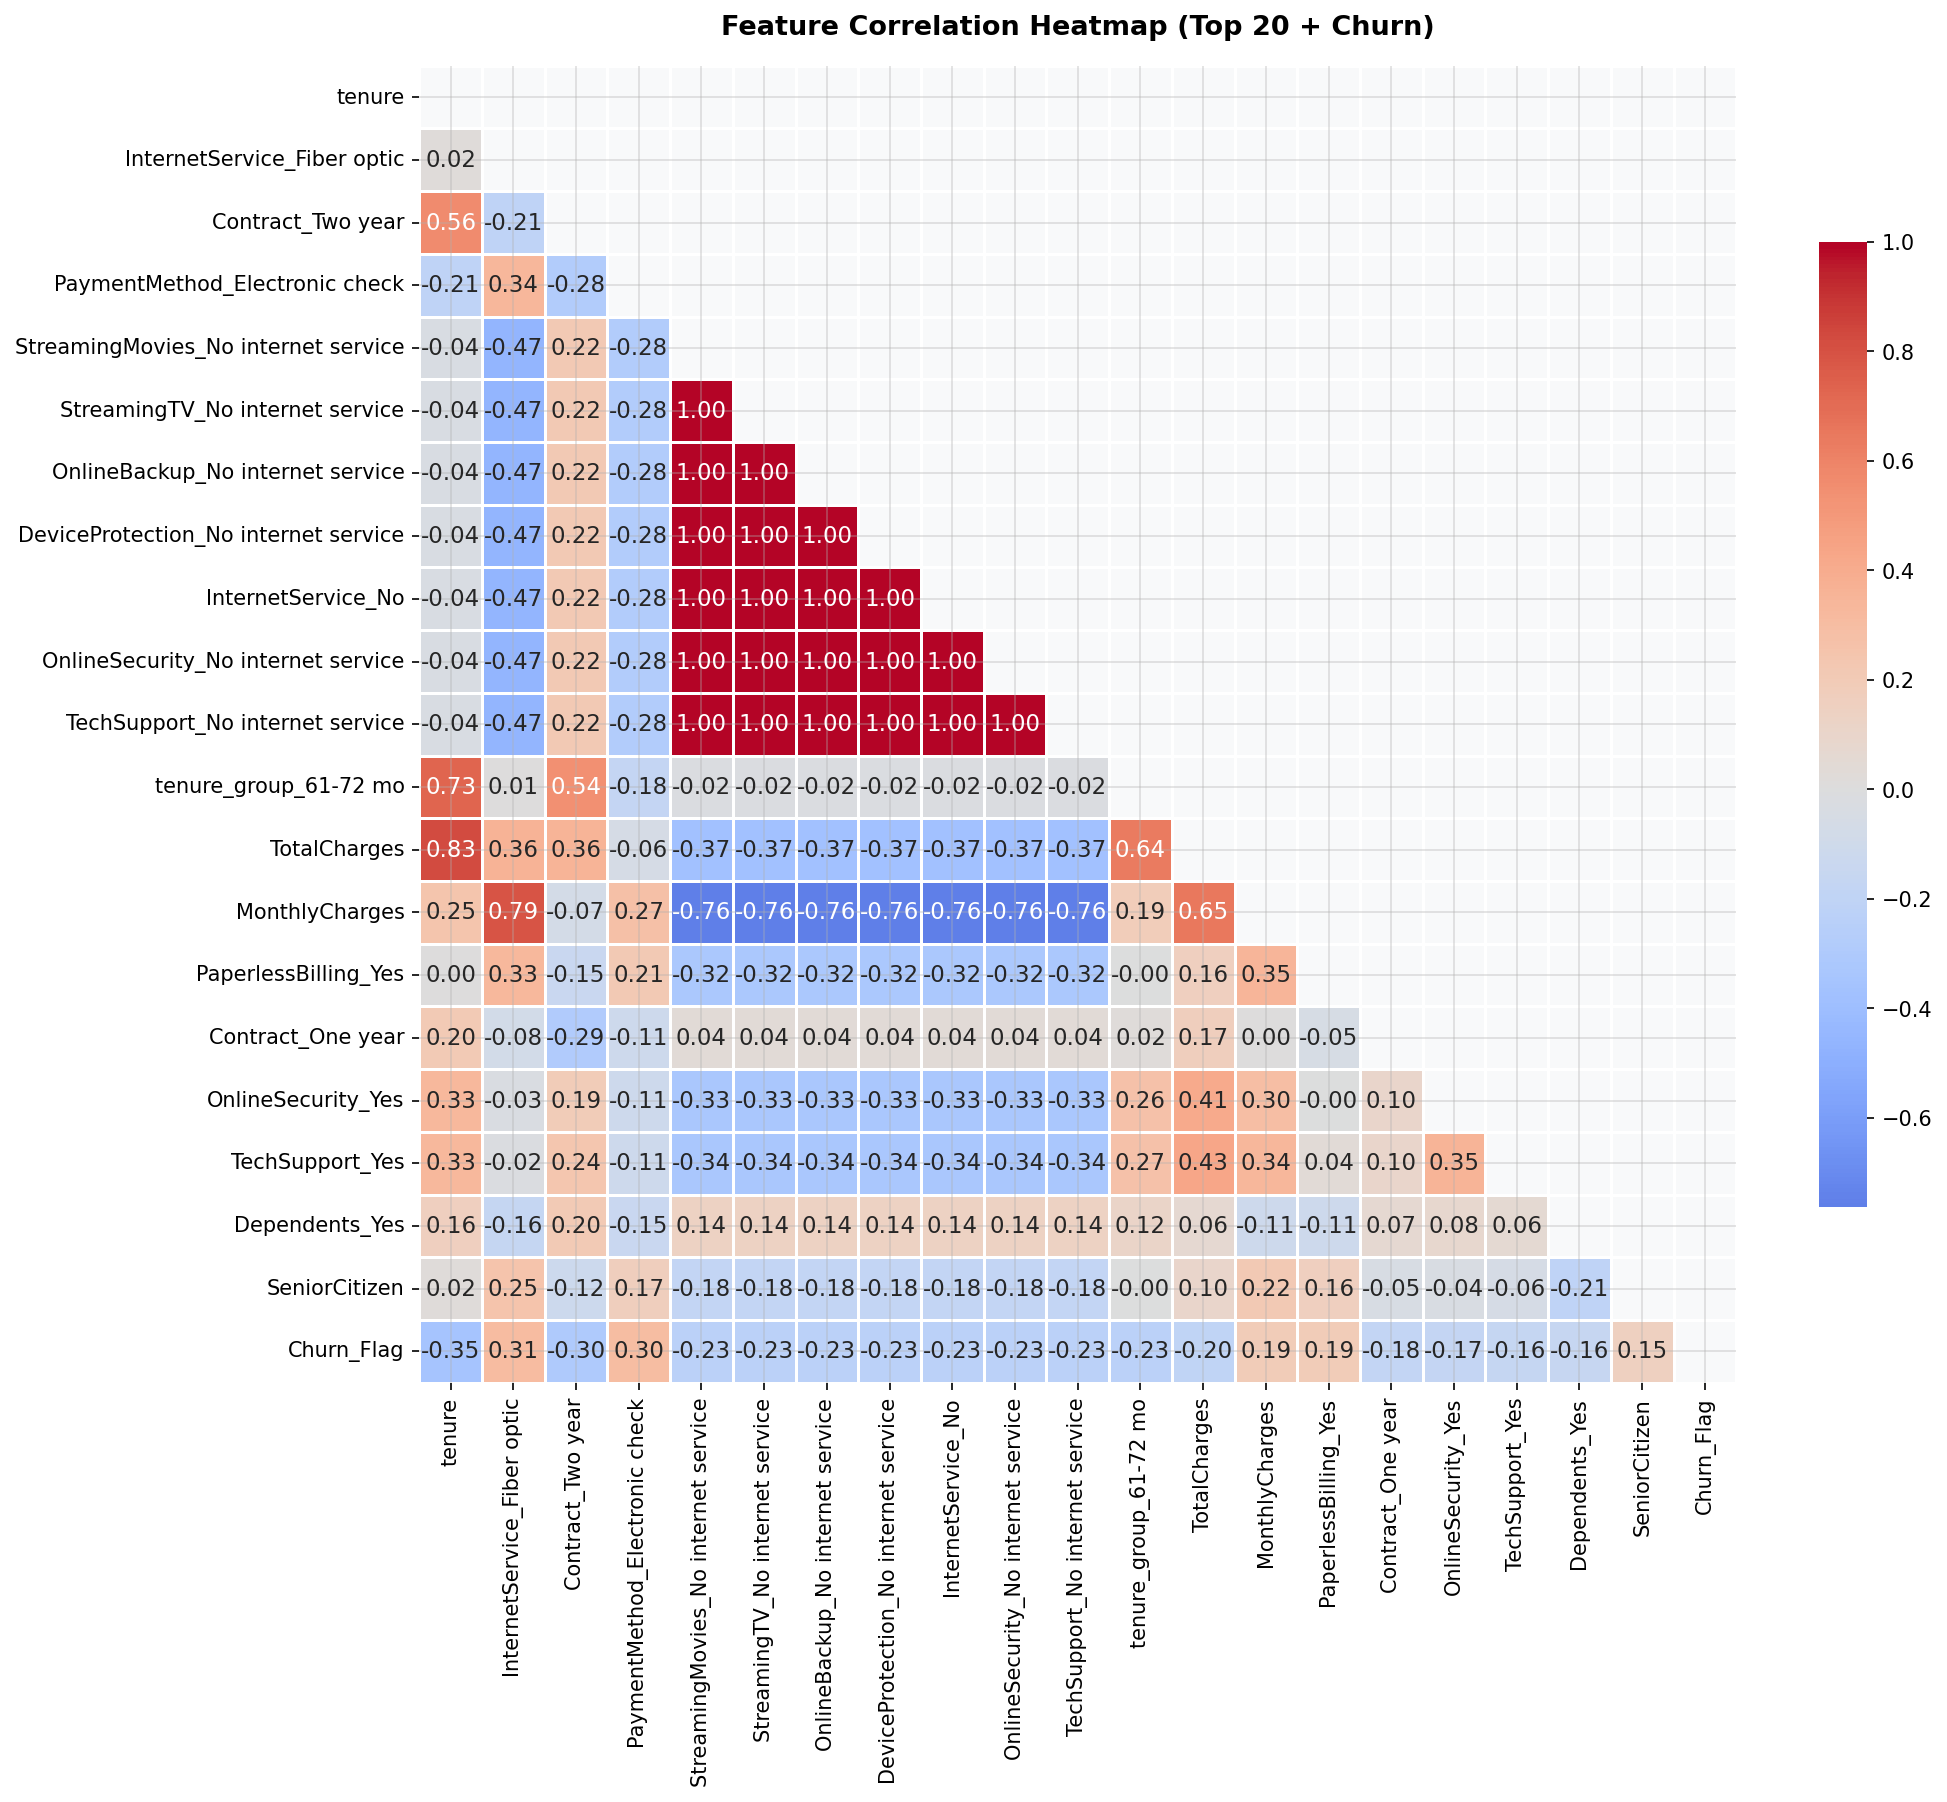

💾  Correlation heatmap saved.


In [49]:
# ── 8.3  Full feature correlation heatmap ────────────────────────────────────
# Use only top-correlated features for readability
top_features = churn_corr.head(20).index.tolist() + ["Churn_Flag"]
corr_matrix  = df_enc[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={"shrink": 0.7}
)
ax.set_title("Feature Correlation Heatmap (Top 20 + Churn)",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(IMG_DIR / "08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Correlation heatmap saved.")

## 9. KDE Charge Distribution by Churn

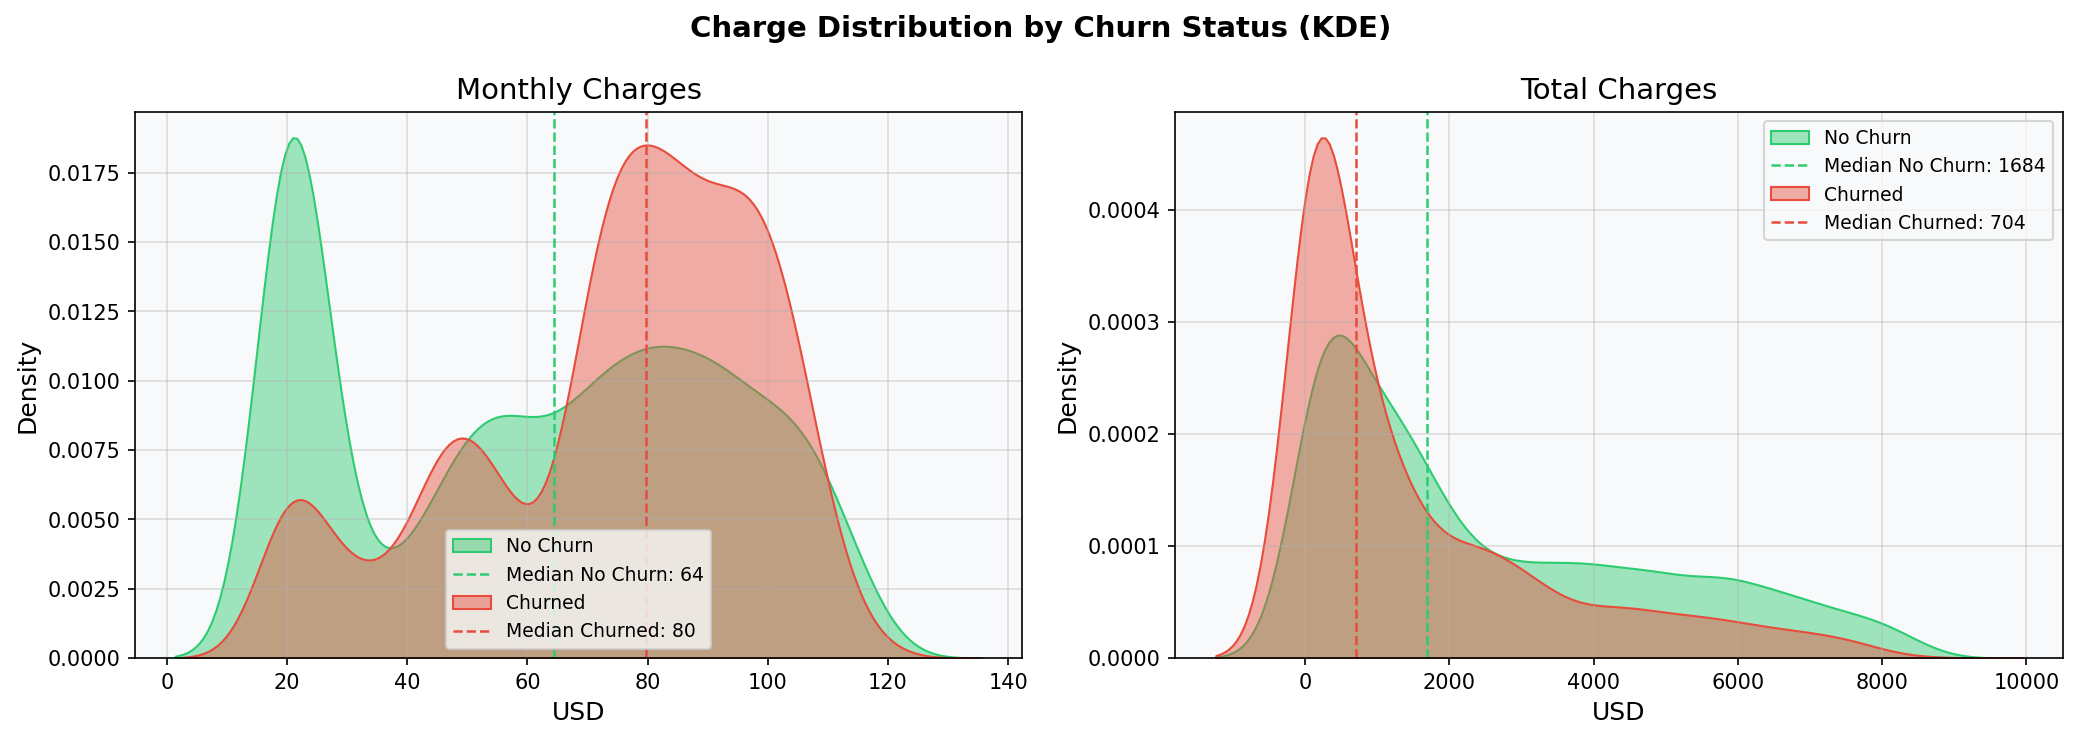

💾  KDE charge plots saved.


In [50]:
# ── 9.1  KDE plots — Monthly & Total Charges split by Churn ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Charge Distribution by Churn Status (KDE)",
             fontsize=14, fontweight="bold")

for ax, col, title in [
    (axes[0], "MonthlyCharges", "Monthly Charges"),
    (axes[1], "TotalCharges",   "Total Charges"),
]:
    for churn_val, label, color in [(0, "No Churn", "#2ecc71"), (1, "Churned", "#e74c3c")]:
        sub = df.loc[df["Churn_Flag"]==churn_val, col].dropna()
        sns.kdeplot(sub, ax=ax, color=color, fill=True, alpha=0.45, label=label)
        ax.axvline(sub.median(), color=color, linestyle="--", linewidth=1.2,
                   label=f"Median {label}: {sub.median():.0f}")
    ax.set_title(title)
    ax.set_xlabel("USD")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(IMG_DIR / "09_kde_charges_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  KDE charge plots saved.")

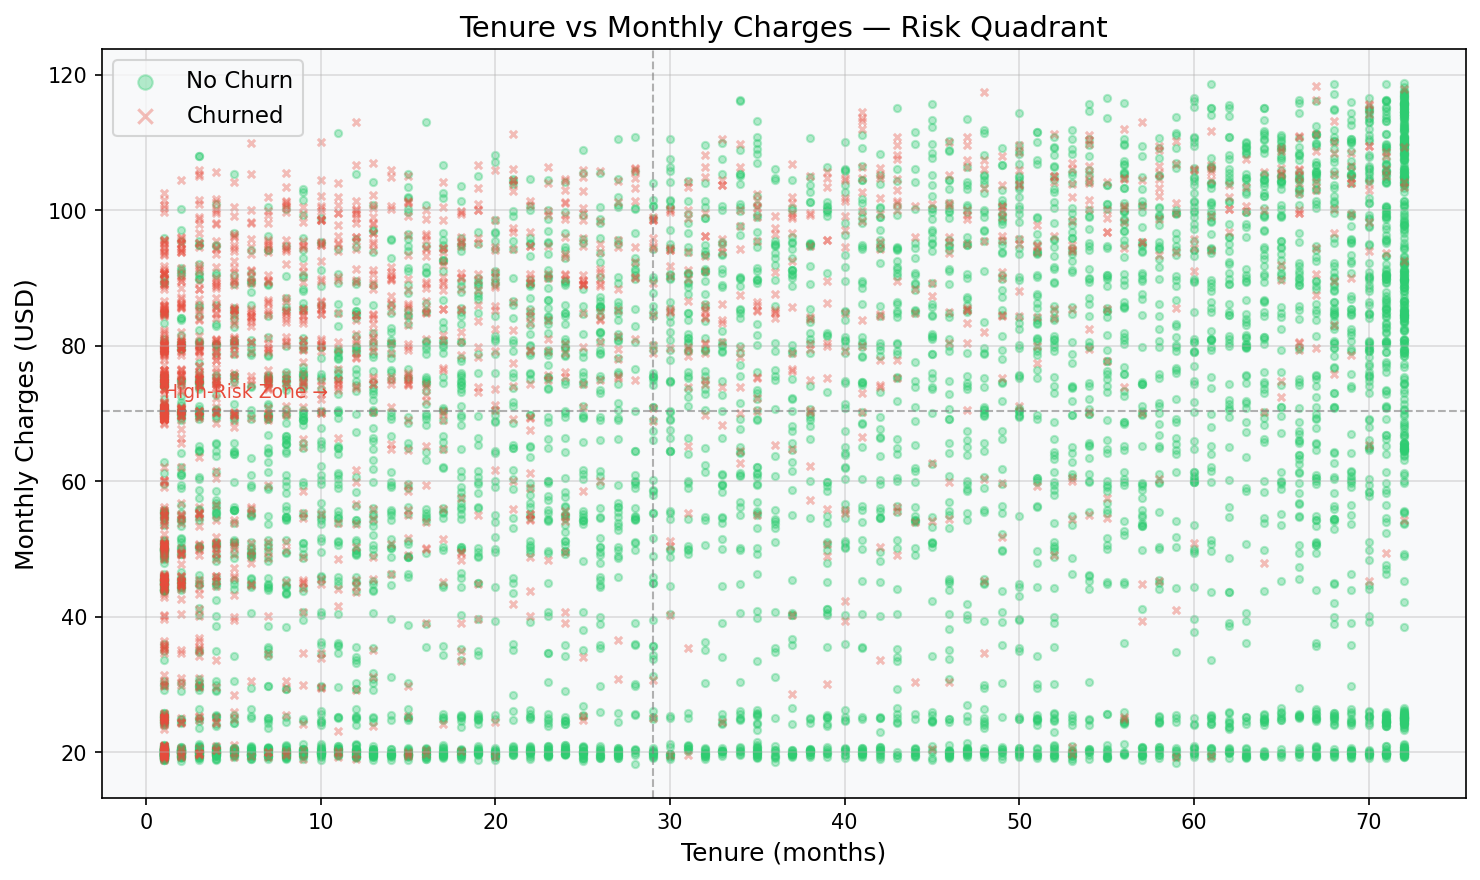

💾  Tenure-charges risk quadrant saved.


In [51]:
# ── 9.2  Tenure x Monthly Charges scatter coloured by Churn ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for churn_val, label, color, marker in [
    (0, "No Churn", "#2ecc71", "o"),
    (1, "Churned",  "#e74c3c", "x"),
]:
    sub = df[df["Churn_Flag"] == churn_val]
    ax.scatter(sub["tenure"], sub["MonthlyCharges"],
               alpha=0.35, s=12, c=color, label=label,
               marker=marker, rasterized=True)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Monthly Charges (USD)")
ax.set_title("Tenure vs Monthly Charges — Risk Quadrant")
ax.legend(markerscale=2)

# Mark high-risk quadrant (high charges, low tenure)
med_tenure = df["tenure"].median()
med_charge = df["MonthlyCharges"].median()
ax.axvline(med_tenure, color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(med_charge, color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.text(1, med_charge + 2, "High-Risk Zone →", color="#e74c3c", fontsize=9)

plt.tight_layout()
plt.savefig(IMG_DIR / "09_tenure_vs_charges_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Tenure-charges risk quadrant saved.")

## 10. Business Insights Summary

In [52]:
# ── 10.1  Compute and print key metrics ──────────────────────────────────────
insights = {}

# Churn rate by contract
insights["churn_by_contract"] = (
    df.groupby("Contract")["Churn_Flag"].mean() * 100
).round(2).to_dict()

# Churn rate by payment method
insights["churn_by_payment"] = (
    df.groupby("PaymentMethod")["Churn_Flag"].mean() * 100
).round(2).to_dict()

# Churn rate by tenure group
insights["churn_by_tenure_group"] = (
    df.groupby("tenure_group")["Churn_Flag"].mean() * 100
).round(2).to_dict()

# Senior citizen churn
insights["churn_senior_vs_non"] = (
    df.groupby("SeniorCitizen_Label")["Churn_Flag"].mean() * 100
).round(2).to_dict()

# Median LTV: churned vs retained
insights["median_ltv"] = (
    df.groupby("Churn")["ltv_proxy"].median()
).round(2).to_dict()

# Print
print(json.dumps(insights, indent=2))

# Save
with open(REPORT_DIR / "10_key_metrics.json", "w") as f:
    json.dump(insights, f, indent=2)
print(f"\n💾  Key metrics JSON saved.")

{
  "churn_by_contract": {
    "Month-to-month": 42.71,
    "One year": 11.28,
    "Two year": 2.85
  },
  "churn_by_payment": {
    "Bank transfer (automatic)": 16.73,
    "Credit card (automatic)": 15.25,
    "Electronic check": 45.29,
    "Mailed check": 19.2
  },
  "churn_by_tenure_group": {
    "1-12 mo": 47.68,
    "13-24 mo": 28.71,
    "25-36 mo": 21.63,
    "37-48 mo": 19.03,
    "49-60 mo": 14.42,
    "61-72 mo": 6.61,
    "73-84 mo": NaN
  },
  "churn_senior_vs_non": {
    "Non-Senior": 23.65,
    "Senior": 41.68
  },
  "median_ltv": {
    "No": 1683.6,
    "Yes": 703.55
  }
}

💾  Key metrics JSON saved.


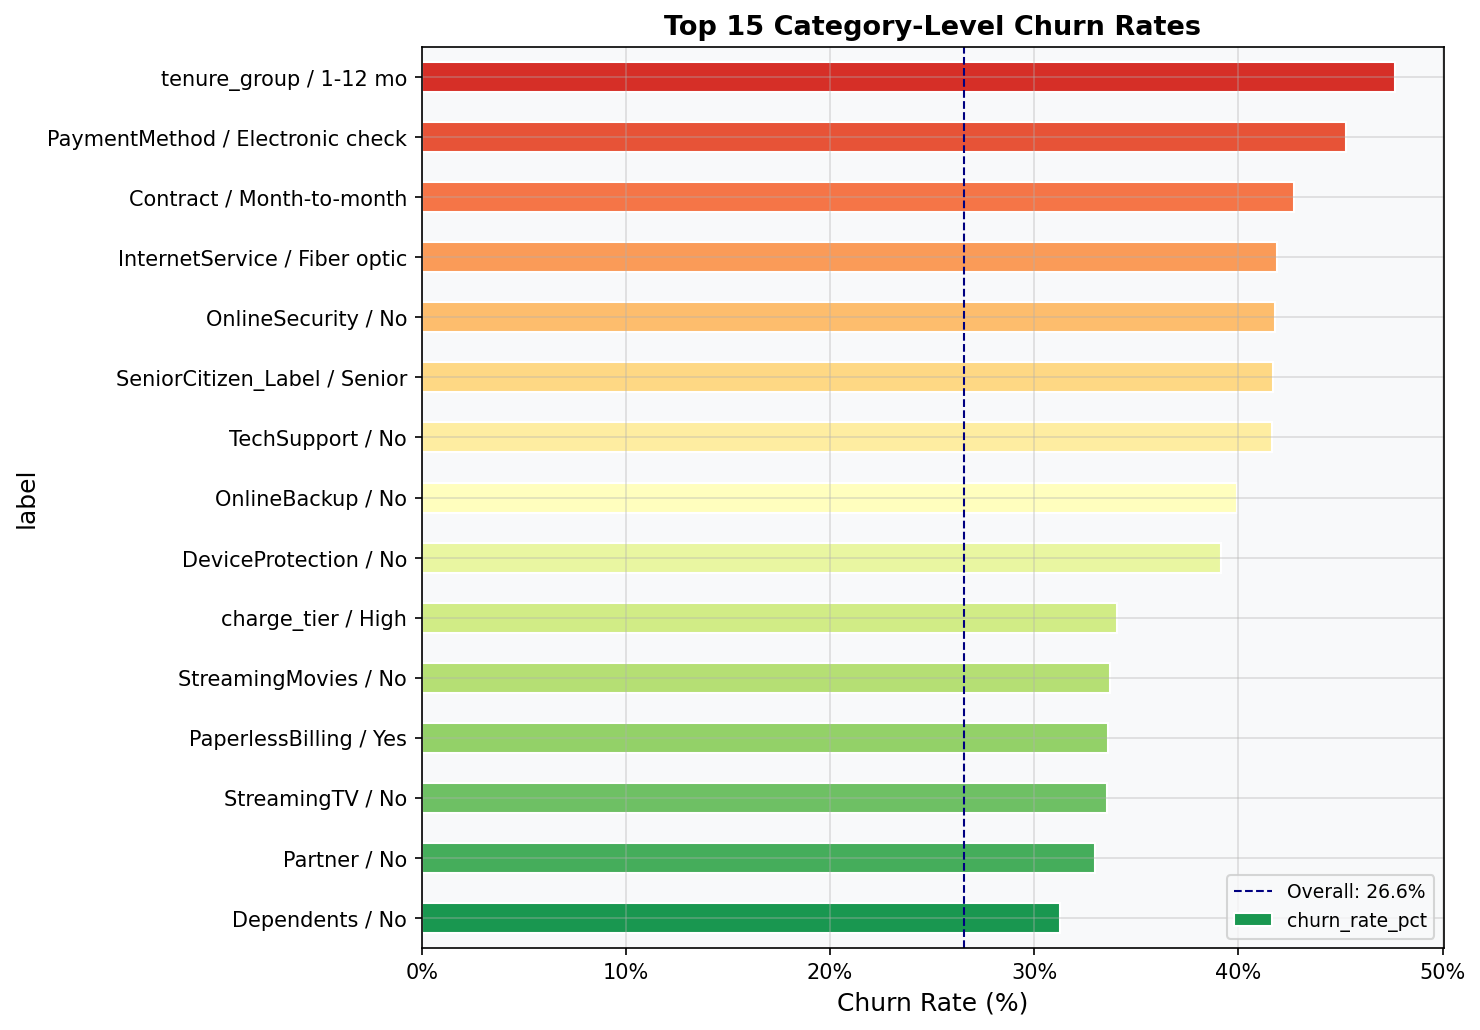

💾  Top-15 churn rate chart saved.


In [53]:
# ── 10.2  Insight summary chart ───────────────────────────────────────────────
# Bar chart ranking churn rate per feature category (top 15 values across all features)
all_churn_rates_df = pd.read_csv(REPORT_DIR / "06_churn_rate_by_category.csv")
top15 = all_churn_rates_df.nlargest(15, "churn_rate_pct").copy()
top15["label"] = top15["feature"] + " / " + top15["category"].astype(str)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
top15.sort_values("churn_rate_pct", ascending=True).plot(
    kind="barh", x="label", y="churn_rate_pct",
    ax=ax, color=colors_bar, legend=False, edgecolor="white"
)
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Top 15 Category-Level Churn Rates",
             fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.axvline(churn_rate, color="navy", linestyle="--", linewidth=1,
           label=f"Overall: {churn_rate:.1f}%")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(IMG_DIR / "10_top15_churn_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾  Top-15 churn rate chart saved.")

In [54]:
# ── 10.3  Print final written summary ────────────────────────────────────────
summary_text = f"""
╔══════════════════════════════════════════════════════════════════╗
║         TELECOM CHURN ANALYSIS — KEY BUSINESS INSIGHTS          ║
╚══════════════════════════════════════════════════════════════════╝

DATASET
  Total customers analysed : {len(df):,}
  Overall churn rate        : {churn_rate:.2f}%
  Class imbalance (No:Yes)  : {df['Churn_Flag'].value_counts()[0]/df['Churn_Flag'].value_counts()[1]:.1f}:1

TOP CHURN DRIVERS
  1. CONTRACT TYPE
     Month-to-month: ~{insights['churn_by_contract'].get('Month-to-month', 'N/A')}%  vs
     Two year:        ~{insights['churn_by_contract'].get('Two year', 'N/A')}%

  2. PAYMENT METHOD
     Electronic check leads churn (~{max(insights['churn_by_payment'].values())}%)

  3. TENURE
     Customers in their first 12 months have the highest churn.

  4. SENIOR CITIZENS
     Senior: ~{insights['churn_senior_vs_non'].get('Senior', 'N/A')}%  vs
     Non-Senior: ~{insights['churn_senior_vs_non'].get('Non-Senior', 'N/A')}%

  5. SERVICES
     Customers without Online Security or Tech Support churn significantly more.

  6. CHARGES
     High monthly charges + short tenure → highest churn risk.
     Median LTV (churned): ${insights['median_ltv'].get('Yes', 'N/A')} vs
     Median LTV (retained): ${insights['median_ltv'].get('No', 'N/A')}

LOW-IMPACT FEATURES
  Gender and Phone Service show minimal churn differentiation.

NEXT STEPS
  → Address class imbalance (SMOTE / class_weight) before modelling
  → Build retention models (Logistic Regression, XGBoost, etc.)
  → Target month-to-month customers with long-term contract incentives
  → Investigate electronic check payment UX for friction reduction
"""
print(summary_text)

# Save as text report
with open(REPORT_DIR / "10_business_summary.txt", "w") as f:
    f.write(summary_text)
print("💾  Business summary saved.")


╔══════════════════════════════════════════════════════════════════╗
║         TELECOM CHURN ANALYSIS — KEY BUSINESS INSIGHTS          ║
╚══════════════════════════════════════════════════════════════════╝

DATASET
  Total customers analysed : 7,032
  Overall churn rate        : 26.58%
  Class imbalance (No:Yes)  : 2.8:1

TOP CHURN DRIVERS
  1. CONTRACT TYPE
     Month-to-month: ~42.71%  vs
     Two year:        ~2.85%

  2. PAYMENT METHOD
     Electronic check leads churn (~45.29%)

  3. TENURE
     Customers in their first 12 months have the highest churn.

  4. SENIOR CITIZENS
     Senior: ~41.68%  vs
     Non-Senior: ~23.65%

  5. SERVICES
     Customers without Online Security or Tech Support churn significantly more.

  6. CHARGES
     High monthly charges + short tenure → highest churn risk.
     Median LTV (churned): $703.55 vs
     Median LTV (retained): $1683.6

LOW-IMPACT FEATURES
  Gender and Phone Service show minimal churn differentiation.

NEXT STEPS
  → Address class i

## 11. Export & ZIP All Outputs

Package every artefact produced during this notebook into a single ZIP file for download.

In [55]:
# ── 11.1  Final encoded dataset ──────────────────────────────────────────────
# Save the model-ready encoded dataframe for downstream ML use
df_enc.to_csv(DATA_DIR / "11_model_ready_encoded.csv", index=False)
print(f"💾  Model-ready data saved → {DATA_DIR / '11_model_ready_encoded.csv'}")

💾  Model-ready data saved → churn_eda_outputs/data/11_model_ready_encoded.csv


In [56]:
# ── 11.2  Create ZIP archive of all outputs ───────────────────────────────────
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
zip_name  = f"churn_eda_outputs_{timestamp}.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            arcname = file_path.relative_to(OUTPUT_DIR.parent)
            zf.write(file_path, arcname)

zip_size_mb = Path(zip_name).stat().st_size / 1_000_000
print(f"\n{'='*55}")
print(f"✅  ZIP archive created: {zip_name}")
print(f"    Size: {zip_size_mb:.2f} MB")
print(f"{'='*55}")

# List contents
print("\nContents:")
with zipfile.ZipFile(zip_name, "r") as zf:
    for name in sorted(zf.namelist()):
        info = zf.getinfo(name)
        print(f"  {name:<65}  {info.file_size/1000:>7.1f} KB")


✅  ZIP archive created: churn_eda_outputs_20260428_080721.zip
    Size: 3.71 MB

Contents:
  churn_eda_outputs/data/01_raw_data.csv                               971.2 KB
  churn_eda_outputs/data/04_cleaned_data.csv                          1197.7 KB
  churn_eda_outputs/data/08_encoded_data.csv                          1422.2 KB
  churn_eda_outputs/data/11_model_ready_encoded.csv                   1422.2 KB
  churn_eda_outputs/images/03a_missing_matrix.png                       88.2 KB
  churn_eda_outputs/images/05_target_distribution.png                   91.5 KB
  churn_eda_outputs/images/06_numeric_distributions.png                231.6 KB
  churn_eda_outputs/images/06_univariate_cat_group1.png                106.6 KB
  churn_eda_outputs/images/06_univariate_cat_group2.png                124.9 KB
  churn_eda_outputs/images/06_univariate_cat_group3.png                103.7 KB
  churn_eda_outputs/images/06_univariate_cat_group4.png                163.8 KB
  churn_eda_outputs/images/0

In [57]:
# ── 11.3  Colab: trigger file download ───────────────────────────────────────
# This cell triggers the browser download dialog on Google Colab.
# If running locally, the ZIP is already in your working directory.
try:
    from google.colab import files
    files.download(zip_name)
    print(f"📥  Download triggered for: {zip_name}")
except ImportError:
    print(f"ℹ️  Not running on Colab.")
    print(f"    ZIP saved locally at: {Path(zip_name).resolve()}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥  Download triggered for: churn_eda_outputs_20260428_080721.zip


In [58]:
# ── 11.4  Final checklist ────────────────────────────────────────────────────
print("""
╔═══════════════════════════════════════════════════╗
║           NOTEBOOK EXECUTION COMPLETE             ║
╠═══════════════════════════════════════════════════╣
║  ✅ Phase 1: Environment Setup                    ║
║  ✅ Phase 2: Data Ingestion                       ║
║  ✅ Phase 3: Data Profiling & Quality Check       ║
║  ✅ Phase 4: Cleaning & Feature Engineering       ║
║  ✅ Phase 5: Target Variable Analysis             ║
║  ✅ Phase 6: Univariate Analysis                  ║
║  ✅ Phase 7: Bivariate Analysis                   ║
║  ✅ Phase 8: Correlation & Heatmap Analysis       ║
║  ✅ Phase 9: KDE Charge Distribution              ║
║  ✅ Phase 10: Business Insights Summary           ║
║  ✅ Phase 11: ZIP Export                          ║
╚═══════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════╗
║           NOTEBOOK EXECUTION COMPLETE             ║
╠═══════════════════════════════════════════════════╣
║  ✅ Phase 1: Environment Setup                    ║
║  ✅ Phase 2: Data Ingestion                       ║
║  ✅ Phase 3: Data Profiling & Quality Check       ║
║  ✅ Phase 4: Cleaning & Feature Engineering       ║
║  ✅ Phase 5: Target Variable Analysis             ║
║  ✅ Phase 6: Univariate Analysis                  ║
║  ✅ Phase 7: Bivariate Analysis                   ║
║  ✅ Phase 8: Correlation & Heatmap Analysis       ║
║  ✅ Phase 9: KDE Charge Distribution              ║
║  ✅ Phase 10: Business Insights Summary           ║
║  ✅ Phase 11: ZIP Export                          ║
╚═══════════════════════════════════════════════════╝

